<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [37]</a>'.</span>

# GSE137136 + GSE133218 - Pro-inflammatory cytokines in human islets and beta cells


**Environment:** `clamp-analyses`


Projects both datasets into the **ARCHS4 CLAMPfull_hall** model.
- PCA of projected LV scores
- Volcano: red = higher in treated, green = higher in control (FDR < 0.01)
- Signed pathway shift plots: log2FC on x, dot size = LV FDR, color = direction
- Pathway dot plots for top 5 up and top 5 down LVs (AUC > 0.7, FDR < 0.05)

GSE133218 uses both pooled IFNa vs control and pairwise comparisons per timepoint (ctrl_Xh vs IFNa_Xh).

| Dataset | Tissue | Treatment |
|---------|--------|-----------|
| GSE137136 | Human pancreatic islets | IL-1β + IFN-γ vs control |
| GSE133218 | EndoC-βH1 beta cell line | IFNα vs control at 2h / 8h / 24h |


## Libraries


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(here)
  library(CLAMP)
  library(ggplot2)
  library(ggrepel)
  library(org.Hs.eg.db)
  library(AnnotationDbi)
  library(limma)
})


## Paths and helpers


In [2]:
out_dir  <- here("output", "03_model_biology", "00_archs4", "03_tissue_projections", "02_pro_inflammatory_cytokines")
data_dir <- file.path(out_dir, "data")
dir.create(data_dir, recursive = TRUE, showWarnings = FALSE)

clean_pathway <- function(x) {
  x <- ifelse(is.na(x) | x == "", "unannotated", x)
  x <- gsub("^HALL_HALLMARK_", "", x)
  x <- gsub("^REACTOME_REACTOME_", "", x)
  x <- gsub("^GOBP_GOBP_|^GOCC_GOCC_|^GOMF_GOMF_", "", x)
  x <- gsub("^C[0-9]+_", "", x)
  x <- gsub("_", " ", x)
  trimws(gsub("\\s+", " ", x))
}

short_label <- function(x, width = 55)
  ifelse(nchar(x) > width, paste0(substr(x, 1, width - 3), "..."), x)


## Load and normalize - GSE137136


In [3]:
raw_path <- file.path(data_dir, "GSE137136_matrix.htseq-count.txt.gz")
geo_url  <- paste0(
  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE137nnn/GSE137136/suppl/",
  "GSE137136%5Fmatrix%2Ehtseq%2Dcount%2Etxt%2Egz"
)

if (!file.exists(raw_path)) {
  download.file(geo_url, raw_path, mode = "wb", quiet = FALSE)
} else {
  message("Using cached file: ", basename(raw_path))
}

dt       <- fread(raw_path)
gene_col <- colnames(dt)[1]
counts_ifn_gamma      <- as.matrix(dt[, -1, with = FALSE])
storage.mode(counts_ifn_gamma) <- "numeric"
rownames(counts_ifn_gamma) <- dt[[gene_col]]
counts_ifn_gamma <- counts_ifn_gamma[!grepl("^__", rownames(counts_ifn_gamma)), , drop = FALSE]

ids_clean <- sub("\\..*", "", rownames(counts_ifn_gamma))
sym_map   <- AnnotationDbi::select(
  org.Hs.eg.db, keys = unique(ids_clean), columns = "SYMBOL", keytype = "ENSEMBL"
)
sym_vec  <- setNames(sym_map$SYMBOL, sym_map$ENSEMBL)
hgnc_ids <- sym_vec[ids_clean]
keep     <- !is.na(hgnc_ids) & hgnc_ids != ""
counts_ifn_gamma      <- counts_ifn_gamma[keep, , drop = FALSE]
rownames(counts_ifn_gamma) <- hgnc_ids[keep]
counts_ifn_gamma <- rowsum(counts_ifn_gamma, rownames(counts_ifn_gamma))

meta_ifn_gamma <- data.frame(
  sample    = colnames(counts_ifn_gamma),
  condition = ifelse(grepl("^ctrl", colnames(counts_ifn_gamma)), "Control", "Cytokine"),
  stringsAsFactors = FALSE
)

cpm_mat  <- cpmCLAMP(counts_ifn_gamma)
prep     <- preprocessCLAMP(Y = cpm_mat, mean_cutoff = 0.5, var_cutoff = 0.1)
norm_ifn_gamma <- zscoreCLAMP(Y_filtered = prep$Y_filtered, rowStats = prep$rowStats)

cat("Normalized matrix:", nrow(norm_ifn_gamma), "genes x", ncol(norm_ifn_gamma), "samples\n")
print(table(meta_ifn_gamma$condition))


'select()' returned 1:many mapping between keys and columns



Normalized matrix: 13066 genes x 10 samples



 Control Cytokine 
       5        5 


## Load and normalize - GSE133218


In [4]:
data_dir_133 <- file.path(data_dir, "GSE133218")
dir.create(data_dir_133, recursive = TRUE, showWarnings = FALSE)

tar_path   <- file.path(data_dir_133, "GSE133218_RAW.tar")
cache_rds  <- file.path(data_dir_133, "GSE133218_counts.rds")
meta_cache <- file.path(data_dir_133, "GSE133218_metadata.csv")

geo_tar_url <- paste0(
  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE133nnn/GSE133218/suppl/",
  "GSE133218_RAW.tar"
)

if (!file.exists(tar_path)) {
  message("Downloading GSE133218_RAW.tar (~126 MB) ...")
  download.file(geo_tar_url, tar_path, mode = "wb", quiet = FALSE)
} else {
  message("Using cached tar: ", basename(tar_path))
}

gtf_files <- list.files(data_dir_133, pattern = "\\.gtf\\.gz$", full.names = TRUE)
if (length(gtf_files) == 0) {
  untar(tar_path, exdir = data_dir_133)
  gtf_files <- list.files(data_dir_133, pattern = "\\.gtf\\.gz$", full.names = TRUE)
}

parse_flux_gtf <- function(path) {
  raw <- fread(
    cmd  = paste("zcat", shQuote(path)),
    sep  = "\t", header = FALSE, quote = "",
    col.names = c("seqname","source","feature","start","end",
                  "score","strand","frame","attributes")
  )
  raw <- raw[feature == "transcript"]
  raw[, gene_id       := sub('.*gene_id "([^"]+)".*', "\\1", attributes)]
  raw[, reads_val     := as.numeric(sub(".*; reads ([0-9.]+);.*", "\\1", attributes))]
  raw[is.na(reads_val), reads_val := 0]
  raw[, gene_id_clean := sub("\\..*", "", gene_id)]
  raw[, .(gene_reads = sum(reads_val, na.rm = TRUE)), by = gene_id_clean]
}

meta_ifn_alpha <- data.frame(
  file      = gtf_files,
  gsm       = sub(".*/(GSM[0-9]+)_.*", "\\1", gtf_files),
  stringsAsFactors = FALSE
)
meta_ifn_alpha$condition <- ifelse(grepl("_Ctl_", basename(gtf_files)), "Control", "IFNa")
meta_ifn_alpha$timepoint <- sub(".*(2h|8h|24h).*", "\\1", basename(gtf_files))
meta_ifn_alpha$group     <- paste0(meta_ifn_alpha$condition, "_", meta_ifn_alpha$timepoint)
meta_ifn_alpha$sample    <- paste0(meta_ifn_alpha$gsm, "_", meta_ifn_alpha$group)

if (!file.exists(cache_rds)) {
  message("Parsing ", length(gtf_files), " GTF files ...")
  expr_list <- lapply(seq_len(nrow(meta_ifn_alpha)), function(i) {
    dt <- parse_flux_gtf(meta_ifn_alpha$file[i])
    setnames(dt, "gene_reads", meta_ifn_alpha$sample[i])
    dt
  })
  merged <- Reduce(function(a, b) merge(a, b, by = "gene_id_clean", all = TRUE), expr_list)
  merged[is.na(merged)] <- 0
  cnt_mat <- as.matrix(merged[, -1, with = FALSE])
  rownames(cnt_mat) <- merged$gene_id_clean
  storage.mode(cnt_mat) <- "numeric"
  saveRDS(cnt_mat, cache_rds)
  write.csv(meta_ifn_alpha, meta_cache, row.names = FALSE)
} else {
  message("Using cached count matrix")
  cnt_mat         <- readRDS(cache_rds)
  meta_ifn_alpha <- read.csv(meta_cache, stringsAsFactors = FALSE)
}

cat("Raw matrix:", nrow(cnt_mat), "genes x", ncol(cnt_mat), "samples\n")
print(table(meta_ifn_alpha$group))


Parsing 30 GTF files ...



Raw matrix: 26346 genes x 30 samples



Control_24h  Control_2h  Control_8h    IFNa_24h     IFNa_2h     IFNa_8h 
          5           5           5           5           5           5 


In [5]:
norm_cache_ifn_alpha   <- file.path(data_dir_133, "GSE133218_norm.rds")
counts_cache_ifn_alpha <- file.path(data_dir_133, "GSE133218_counts_sym.rds")

if (!file.exists(norm_cache_ifn_alpha) || !file.exists(counts_cache_ifn_alpha)) {
  ids_133          <- rownames(cnt_mat)
  sym_map_133      <- AnnotationDbi::select(
    org.Hs.eg.db, keys = unique(ids_133), columns = "SYMBOL", keytype = "ENSEMBL"
  )
  sym_vec_133      <- setNames(sym_map_133$SYMBOL, sym_map_133$ENSEMBL)
  hgnc_133         <- sym_vec_133[ids_133]
  keep_133         <- !is.na(hgnc_133) & hgnc_133 != ""
  counts_ifn_alpha <- cnt_mat[keep_133, , drop = FALSE]
  rownames(counts_ifn_alpha) <- hgnc_133[keep_133]
  counts_ifn_alpha <- rowsum(counts_ifn_alpha, rownames(counts_ifn_alpha))
  cpm_ifn_alpha    <- sweep(counts_ifn_alpha, 2, colSums(counts_ifn_alpha) / 1e6, FUN = "/")
  prep_ifn_alpha   <- preprocessCLAMP(Y = cpm_ifn_alpha, mean_cutoff = 0.5, var_cutoff = 0.1)
  norm_ifn_alpha   <- zscoreCLAMP(Y_filtered = prep_ifn_alpha$Y_filtered,
                                   rowStats   = prep_ifn_alpha$rowStats)
  saveRDS(norm_ifn_alpha,    norm_cache_ifn_alpha)
  saveRDS(counts_ifn_alpha,  counts_cache_ifn_alpha)
}
norm_ifn_alpha   <- readRDS(norm_cache_ifn_alpha)
counts_ifn_alpha <- readRDS(counts_cache_ifn_alpha)

cat("Normalized matrix:", nrow(norm_ifn_alpha), "genes x", ncol(norm_ifn_alpha), "samples\n")

'select()' returned 1:many mapping between keys and columns



Normalized matrix: 13232 genes x 30 samples


## Load ARCHS4 model


In [6]:
model <- readRDS(here("output", "01_model_building", "04_archs4", "06_bp_coverage_rshall", "06_bp_coverage_hall_rs_100", "hall_coverage_rs100_seed_1", "CLAMPfull_hall.rds"))

n_sig <- sum(model$summary$FDR < 0.05 & model$summary$AUC > 0.7, na.rm = TRUE)
cat("ARCHS4 - genes:", nrow(model$Z), "| LVs:", ncol(model$Z),
    "| pathway annotations (AUC>0.7, FDR<0.05):", n_sig, "\n")


ARCHS4 - genes: 18423 | LVs: 1728 | pathway annotations (AUC>0.7, FDR<0.05): 1794 


## Helper functions


In [7]:
wrap_label <- function(x, width = 38)
  sapply(x, function(s) paste(strwrap(s, width = width), collapse = "\n"),
         USE.NAMES = FALSE)

build_annot <- function(mdl) {
  mdl$summary %>%
    dplyr::filter(FDR < 0.05, AUC > 0.7) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), .by_group = TRUE) %>%
    dplyr::summarise(
      pathways = paste(clean_pathway(pathway), collapse = " | "),
      top_AUC  = max(AUC),
      n_paths  = dplyr::n(),
      .groups  = "drop"
    )
}

project_model <- function(mdl, norm_mat) {
  common <- intersect(rownames(mdl$Z), rownames(norm_mat))
  m_sub  <- mdl
  m_sub$Z <- as.matrix(mdl$Z[common, , drop = FALSE])
  B <- projectCLAMP(CLAMPres = m_sub, newdata = norm_mat[common, , drop = FALSE])
  cat("Common genes:", length(common),
      sprintf("(%.1f%% of model genes)\n", 100 * length(common) / nrow(mdl$Z)))
  B
}

rank_lvs <- function(B, meta, mdl, contrast = c("Cytokine", "Control")) {
  cond   <- factor(meta$condition[match(colnames(B), meta$sample)], levels = contrast)
  design <- model.matrix(~ 0 + cond)
  colnames(design) <- levels(cond)
  fit <- lmFit(B, design)
  fit <- contrasts.fit(fit, makeContrasts(
    contrasts = paste0(contrast[1], "-", contrast[2]), levels = design
  ))
  fit <- eBayes(fit)
  de  <- topTable(fit, n = Inf, adjust.method = "BH", sort.by = "P")
  de$LV <- rownames(de)
  de %>%
    dplyr::left_join(build_annot(mdl), by = "LV") %>%
    dplyr::mutate(
      pathways  = dplyr::if_else(is.na(pathways), "unannotated", pathways),
      top_AUC   = dplyr::if_else(is.na(top_AUC), 0, top_AUC),
      n_paths   = dplyr::if_else(is.na(n_paths), 0L, as.integer(n_paths)),
      abs_logFC = abs(logFC)
    ) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC))
}

rank_lvs_6grp <- function(B, meta, mdl) {
  grp_levels <- c("Control_2h", "Control_8h", "Control_24h",
                  "IFNa_2h",    "IFNa_8h",    "IFNa_24h")
  grp    <- factor(meta$group[match(colnames(B), meta$sample)], levels = grp_levels)
  design <- model.matrix(~ 0 + grp)
  colnames(design) <- grp_levels
  fit <- lmFit(B, design)
  fit <- contrasts.fit(fit, makeContrasts(
    tp_2h  = IFNa_2h  - Control_2h,
    tp_8h  = IFNa_8h  - Control_8h,
    tp_24h = IFNa_24h - Control_24h,
    levels = design
  ))
  fit <- eBayes(fit)
  annot <- build_annot(mdl)
  lapply(
    setNames(c("tp_2h", "tp_8h", "tp_24h"), c("2h", "8h", "24h")),
    function(coef_nm) {
      de <- topTable(fit, coef = coef_nm, n = Inf, adjust.method = "BH", sort.by = "P")
      de$LV <- rownames(de)
      de %>%
        dplyr::left_join(annot, by = "LV") %>%
        dplyr::mutate(
          pathways  = dplyr::if_else(is.na(pathways), "unannotated", pathways),
          top_AUC   = dplyr::if_else(is.na(top_AUC), 0, top_AUC),
          n_paths   = dplyr::if_else(is.na(n_paths), 0L, as.integer(n_paths)),
          abs_logFC = abs(logFC)
        ) %>%
        dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC))
    }
  )
}

make_pca_plot <- function(B, meta,
                          colors = c(Control = "#2C7FB8", Cytokine = "#D95F0E", IFNa = "#8B0000")) {
  pca  <- prcomp(t(B), scale. = TRUE)
  vexp <- round(100 * summary(pca)$importance[2, 1:2], 1)
  df   <- as.data.frame(pca$x[, 1:2])
  df$sample    <- rownames(df)
  df$condition <- meta$condition[match(df$sample, meta$sample)]
  ggplot(df, aes(PC1, PC2, color = condition, label = sample)) +
    geom_point(size = 3.5, alpha = 0.9) +
    ggrepel::geom_text_repel(size = 2.8, show.legend = FALSE) +
    scale_color_manual(values = colors, na.value = "grey60") +
    labs(x = paste0("PC1 (", vexp[1], "%)"),
         y = paste0("PC2 (", vexp[2], "%)"),
         color = NULL) +
    theme_bw(base_size = 12)
}

make_volcano <- function(lv_ranked, fdr_cutoff = 0.01, lfc_cutoff = 0.2, label_top = 20) {
  df <- lv_ranked %>%
    dplyr::mutate(
      dir = dplyr::case_when(
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC > 0 ~ "up",
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC < 0 ~ "down",
        TRUE ~ "ns"
      ),
      neg_log10 = pmin(-log10(adj.P.Val), 60)
    )
  top_ids <- df %>%
    dplyr::filter(dir != "ns") %>%
    dplyr::arrange(dplyr::desc(abs_logFC)) %>%
    dplyr::slice_head(n = label_top) %>%
    dplyr::pull(LV)
  df <- df %>%
    dplyr::mutate(label = dplyr::if_else(LV %in% top_ids, LV, NA_character_))
  ggplot(df, aes(logFC, neg_log10, color = dir)) +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "grey50") +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dotted", color = "grey40") +
    geom_point(alpha = 0.7, size = 1.8) +
    ggrepel::geom_text_repel(
      aes(label = label), size = 2.8, max.overlaps = 25,
      show.legend = FALSE, na.rm = TRUE
    ) +
    scale_color_manual(
      values = c(up = "#d73027", down = "#1a9850", ns = "grey70"),
      guide  = "none"
    ) +
    labs(x = "log2 fold-change (treated vs control)", y = "-log10(FDR)") +
    theme_bw(base_size = 12)
}

make_pathway_dot <- function(lv_ranked, mdl, direction = "up",
                              fdr_cutoff = 0.01, lfc_cutoff = 0.2) {
  sig_lvs <- lv_ranked %>%
    dplyr::filter(adj.P.Val < fdr_cutoff, abs_logFC >= lfc_cutoff,
                  if (direction == "up") logFC > 0 else logFC < 0) %>%
    dplyr::arrange(dplyr::desc(abs_logFC)) %>%
    dplyr::pull(LV)
  if (length(sig_lvs) == 0) { message("No sig LVs"); return(invisible(NULL)) }
  path_df <- mdl$summary %>%
    dplyr::filter(LV %in% sig_lvs, FDR < 0.05, AUC > 0.7) %>%
    dplyr::mutate(
      pathway_label = wrap_label(clean_pathway(pathway), width = 38),
      LV            = factor(LV, levels = sig_lvs),
      neg_log10_fdr = -log10(FDR)
    )
  if (nrow(path_df) == 0) { message("No annotated pathways"); return(invisible(NULL)) }
  ggplot(path_df, aes(x = neg_log10_fdr,
                      y = reorder(pathway_label, neg_log10_fdr),
                      color = LV, size = AUC)) +
    geom_point(alpha = 0.85) +
    scale_size_continuous(name = "AUC", range = c(1, 4)) +
    labs(x = "-log10(FDR)", y = NULL, color = "LV") +
    theme_bw(base_size = 10) +
    theme(legend.position = "right",
          axis.text.y    = element_text(size = 7.5, lineheight = 0.9),
          plot.margin    = margin(5, 10, 5, 20, "mm"))
}

make_signed_pathway_shift_plot <- function(lv_ranked, mdl,
                                           fdr_cutoff = 0.01,
                                           lfc_cutoff = 0.2,
                                           pathway_fdr_cutoff = 0.05,
                                           auc_cutoff = 0.7,
                                           top_n_per_direction = 10,
                                           max_paths_per_lv = 1,
                                           label_width = 55,
                                           treated_name = "cytokine",
                                           control_name = "control",
                                           title = NULL) {
  empty_plot <- function(label) {
    p <- ggplot() + theme_void() +
      annotate("text", x = 0.5, y = 0.5, label = label,
               size = 4, colour = "grey60", hjust = 0.5)
    attr(p, "suggested_width") <- 7
    attr(p, "suggested_height") <- 5
    p
  }

  direction_levels <- c(
    paste0("Higher in ", control_name),
    paste0("Higher in ", treated_name)
  )

  annot <- mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::arrange(LV, dplyr::desc(AUC), FDR)

  lv_top <- lv_ranked %>%
    dplyr::mutate(
      direction = dplyr::case_when(
        logFC > 0 ~ direction_levels[2],
        logFC < 0 ~ direction_levels[1],
        TRUE ~ NA_character_
      ),
      neg_log10_fdr = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    ) %>%
    dplyr::filter(
      adj.P.Val < fdr_cutoff,
      abs_logFC >= lfc_cutoff,
      LV %in% annot$LV,
      !is.na(direction)
    ) %>%
    dplyr::group_by(direction) %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val, .by_group = TRUE) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup()

  if (nrow(lv_top) == 0) {
    return(empty_plot("no annotated significant LVs"))
  }

  top_paths <- annot %>%
    dplyr::filter(LV %in% lv_top$LV) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), FDR, .by_group = TRUE) %>%
    dplyr::slice_head(n = max_paths_per_lv) %>%
    dplyr::ungroup()

  plot_df <- lv_top %>%
    dplyr::inner_join(top_paths, by = "LV") %>%
    dplyr::arrange(dplyr::desc(logFC), dplyr::desc(AUC), FDR) %>%
    dplyr::mutate(
      pathway_clean = toupper(clean_pathway(pathway)),
      row_label = wrap_label(paste0(LV, " | ", pathway_clean), width = label_width),
      row_label = factor(row_label, levels = rev(unique(row_label))),
      direction = factor(direction, levels = direction_levels)
    )

  x_lim <- max(abs(plot_df$logFC), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1

  p <- ggplot(plot_df, aes(x = logFC, y = row_label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55", linewidth = 0.35) +
    geom_point(aes(size = neg_log10_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(
      values = setNames(c("#2C7FB8", "#D95F0E"), direction_levels),
      drop = FALSE,
      name = NULL
    ) +
    scale_size_continuous(
      range = c(2.4, 7.5),
      breaks = pretty(plot_df$neg_log10_fdr, n = 4),
      name = "-log10(FDR)",
      guide = guide_legend(override.aes = list(colour = "#222222"))
    ) +
    scale_x_continuous(
      limits = c(-x_lim, x_lim),
      breaks = pretty(c(-x_lim, x_lim), n = 5),
      expand = expansion(mult = c(0.02, 0.02))
    ) +
    labs(
      title = title,
      x = paste0("log2 fold-change (", treated_name, " vs ", control_name, ")"),
      y = NULL
    ) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      panel.grid.major = element_line(colour = "#e5e5e5", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.text.y = element_text(size = 7.8, colour = "grey30", lineheight = 0.9),
      axis.text.x = element_text(size = 9, colour = "grey30"),
      axis.title.x = element_text(size = 10, margin = margin(t = 5)),
      axis.ticks.y = element_blank(),
      legend.position = "right",
      legend.title = element_text(size = 9),
      legend.text = element_text(size = 8),
      legend.key = element_blank(),
      plot.margin = margin(5, 10, 5, 5, "mm")
    )

  attr(p, "suggested_width") <- 8.5
  attr(p, "suggested_height") <- max(6, 0.34 * nrow(plot_df) + 2)
  attr(p, "plot_data") <- plot_df
  p
}

make_ifna_heatmap <- function(rank_133_list, mdl = model,
                              de_fdr_cutoff = 0.05, lfc_cutoff = 0.2,
                              pathway_fdr_cutoff = 0.05, auc_cutoff = 0.7,
                              max_lvs = 40,
                              label_width = 45) {

  annot <- mdl$summary %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::mutate(pathway = clean_pathway(pathway)) %>%
    dplyr::arrange(LV, dplyr::desc(AUC), FDR)

  annotated_lvs <- unique(annot$LV)

  sig_lvs <- unique(unlist(lapply(rank_133_list, function(r) {
    r %>%
      dplyr::filter(
        adj.P.Val < de_fdr_cutoff,
        abs_logFC >= lfc_cutoff,
        LV %in% annotated_lvs
      ) %>%
      dplyr::pull(LV)
  })))

  if (length(sig_lvs) == 0) {
    message("No annotated sig LVs")
    return(invisible(NULL))
  }

  lv_order <- dplyr::bind_rows(lapply(rank_133_list, function(r) {
    r %>%
      dplyr::filter(LV %in% sig_lvs) %>%
      dplyr::select(LV, logFC)
  })) %>%
    dplyr::group_by(LV) %>%
    dplyr::summarise(max_abs = max(abs(logFC), na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(max_abs)) %>%
    dplyr::slice_head(n = max_lvs) %>%
    dplyr::pull(LV)

  lv_annot <- annot %>%
    dplyr::filter(LV %in% lv_order) %>%
    dplyr::group_by(LV) %>%
    dplyr::summarise(
      pathway_label = paste(wrap_label(pathway, width = label_width), collapse = "\n"),
      n_paths = dplyr::n(),
      .groups = "drop"
    ) %>%
    dplyr::mutate(
      lv_label = paste0(LV, "\n", pathway_label)
    )

  hm_df <- dplyr::bind_rows(lapply(names(rank_133_list), function(tp) {
    rank_133_list[[tp]] %>%
      dplyr::filter(LV %in% lv_order) %>%
      dplyr::select(LV, logFC) %>%
      dplyr::mutate(timepoint = tp)
  })) %>%
    dplyr::inner_join(lv_annot %>% dplyr::select(LV, lv_label), by = "LV") %>%
    dplyr::mutate(
      timepoint = factor(timepoint, levels = c("2h", "8h", "24h")),
      lv_label = factor(
        lv_label,
        levels = lv_annot$lv_label[match(rev(lv_order), lv_annot$LV)]
      )
    )

  lim <- max(abs(hm_df$logFC), na.rm = TRUE)

  ggplot(hm_df, aes(timepoint, lv_label, fill = logFC)) +
    geom_tile(
      color = "white",
      linewidth = 0.4,
      width = 0.38,
      height = 0.82
    ) +
    scale_fill_gradient2(
      low = "#1a9850",
      mid = "white",
      high = "#d73027",
      midpoint = 0,
      limits = c(-lim, lim),
      name = "log2FC"
    ) +
    scale_x_discrete(expand = expansion(add = 0.85)) +
    labs(x = NULL, y = NULL) +
    theme_bw(base_size = 10) +
    theme(
      axis.text.y = element_text(
        size = 8.5,
        lineheight = 0.95,
        hjust = 1
      ),
      axis.text.x = element_text(size = 12),
      panel.grid = element_blank(),
      plot.margin = margin(5, 10, 5, 180, "mm"),
      legend.title = element_text(size = 10),
      legend.text = element_text(size = 9)
    )
}


## GSE137136 - IL-1β + IFN-γ vs control


In [8]:
B_ifn_gamma    <- project_model(model, norm_ifn_gamma)
rank_ifn_gamma <- rank_lvs(B_ifn_gamma, meta_ifn_gamma, model, contrast = c("Cytokine", "Control"))

n_up <- sum(rank_ifn_gamma$adj.P.Val < 0.05 & rank_ifn_gamma$logFC > 0)
n_dn <- sum(rank_ifn_gamma$adj.P.Val < 0.05 & rank_ifn_gamma$logFC < 0)
cat("Sig LVs (FDR<0.05): up =", n_up, "| down =", n_dn, "\n")


Common genes: 12248 (66.5% of model genes)


Sig LVs (FDR<0.05): up = 319 | down = 371 


### PCA - GSE137136


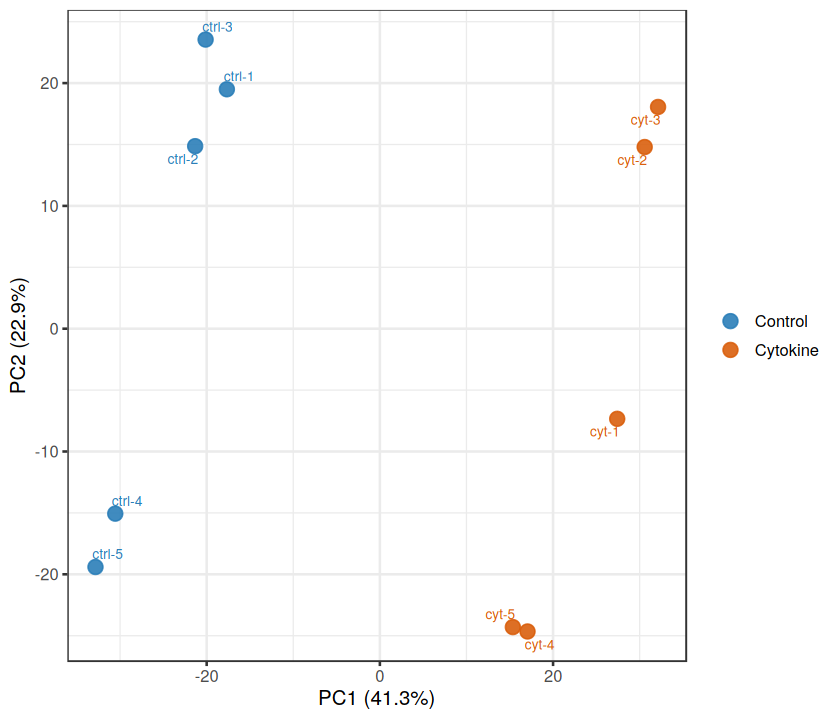

In [9]:
options(repr.plot.width = 7, repr.plot.height = 6)
print(make_pca_plot(B_ifn_gamma, meta_ifn_gamma))


### Volcano - GSE137136


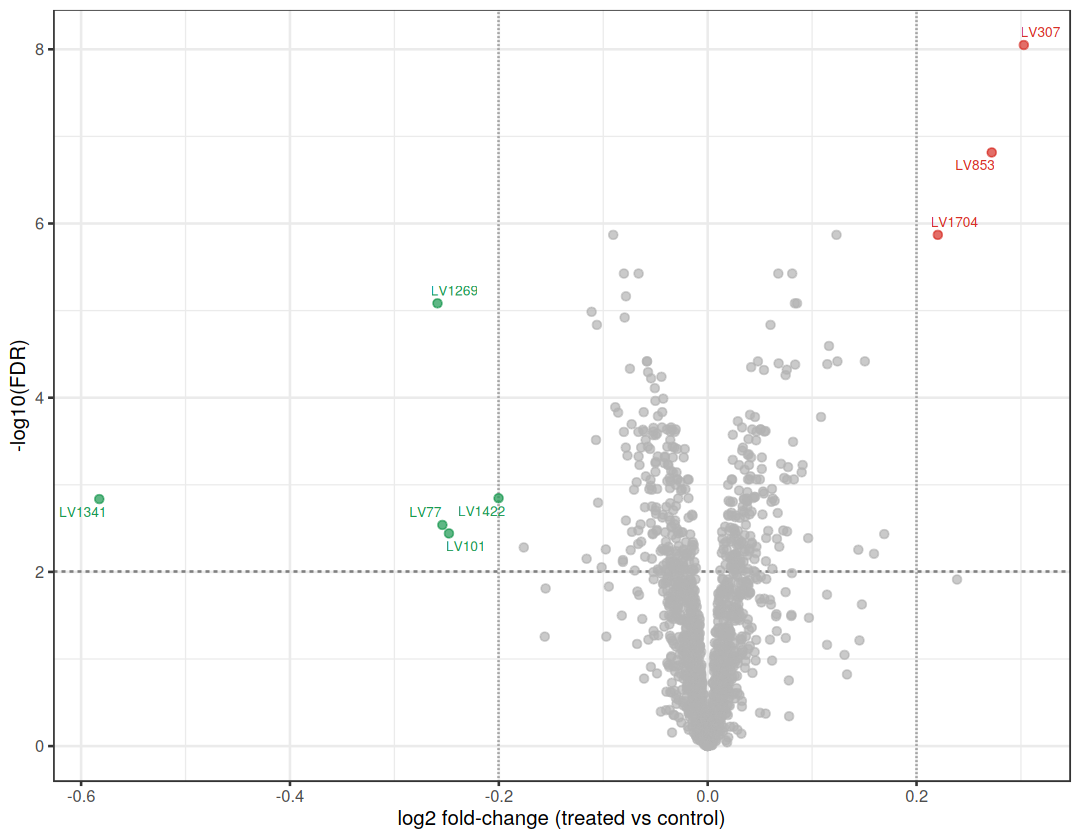

In [10]:
options(repr.plot.width = 9, repr.plot.height = 7)
print(make_volcano(rank_ifn_gamma))


### Signed pathway shift - GSE137136

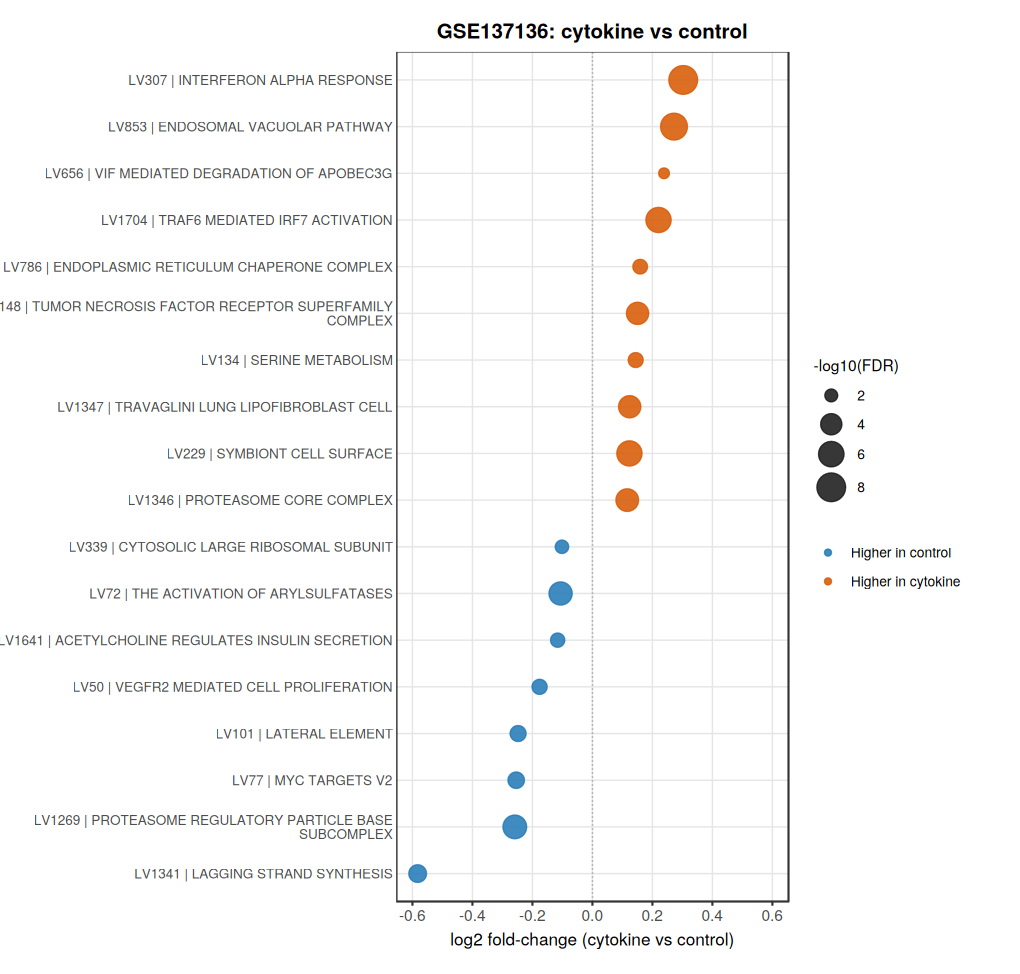

In [11]:
p_ifn_gamma_signed <- make_signed_pathway_shift_plot(
  rank_ifn_gamma,
  model,
  treated_name = "cytokine",
  control_name = "control",
  title = "GSE137136: cytokine vs control",
  fdr_cutoff = 0.05,
  lfc_cutoff = 0.1
)

options(
  repr.plot.width = attr(p_ifn_gamma_signed, "suggested_width"),
  repr.plot.height = attr(p_ifn_gamma_signed, "suggested_height")
)

print(p_ifn_gamma_signed)

### Pathway dot plots - GSE137136

Top 5 LVs by |logFC| in each direction (FDR < 0.01). Points show all significant pathways (AUC > 0.7, FDR < 0.05) for those LVs.


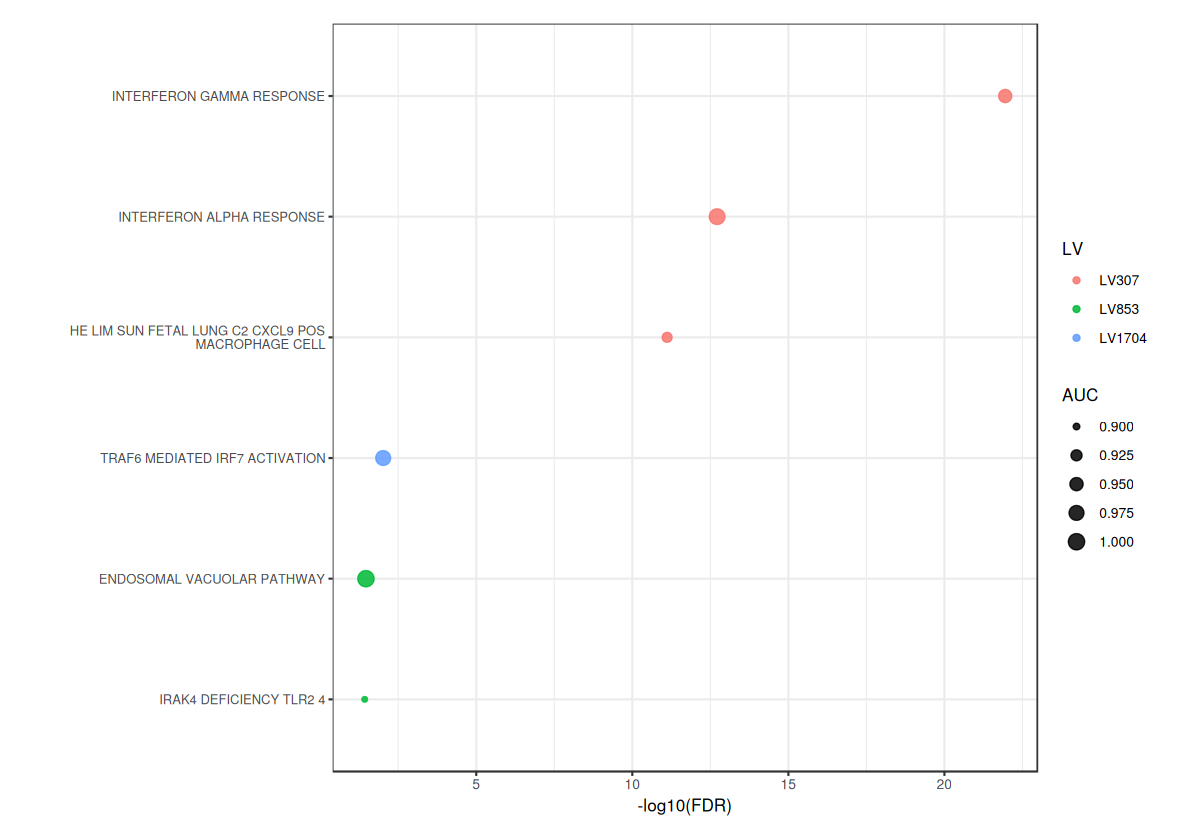

In [12]:
options(repr.plot.width = 10, repr.plot.height = 7)
print(make_pathway_dot(rank_ifn_gamma, model, direction = "up"))


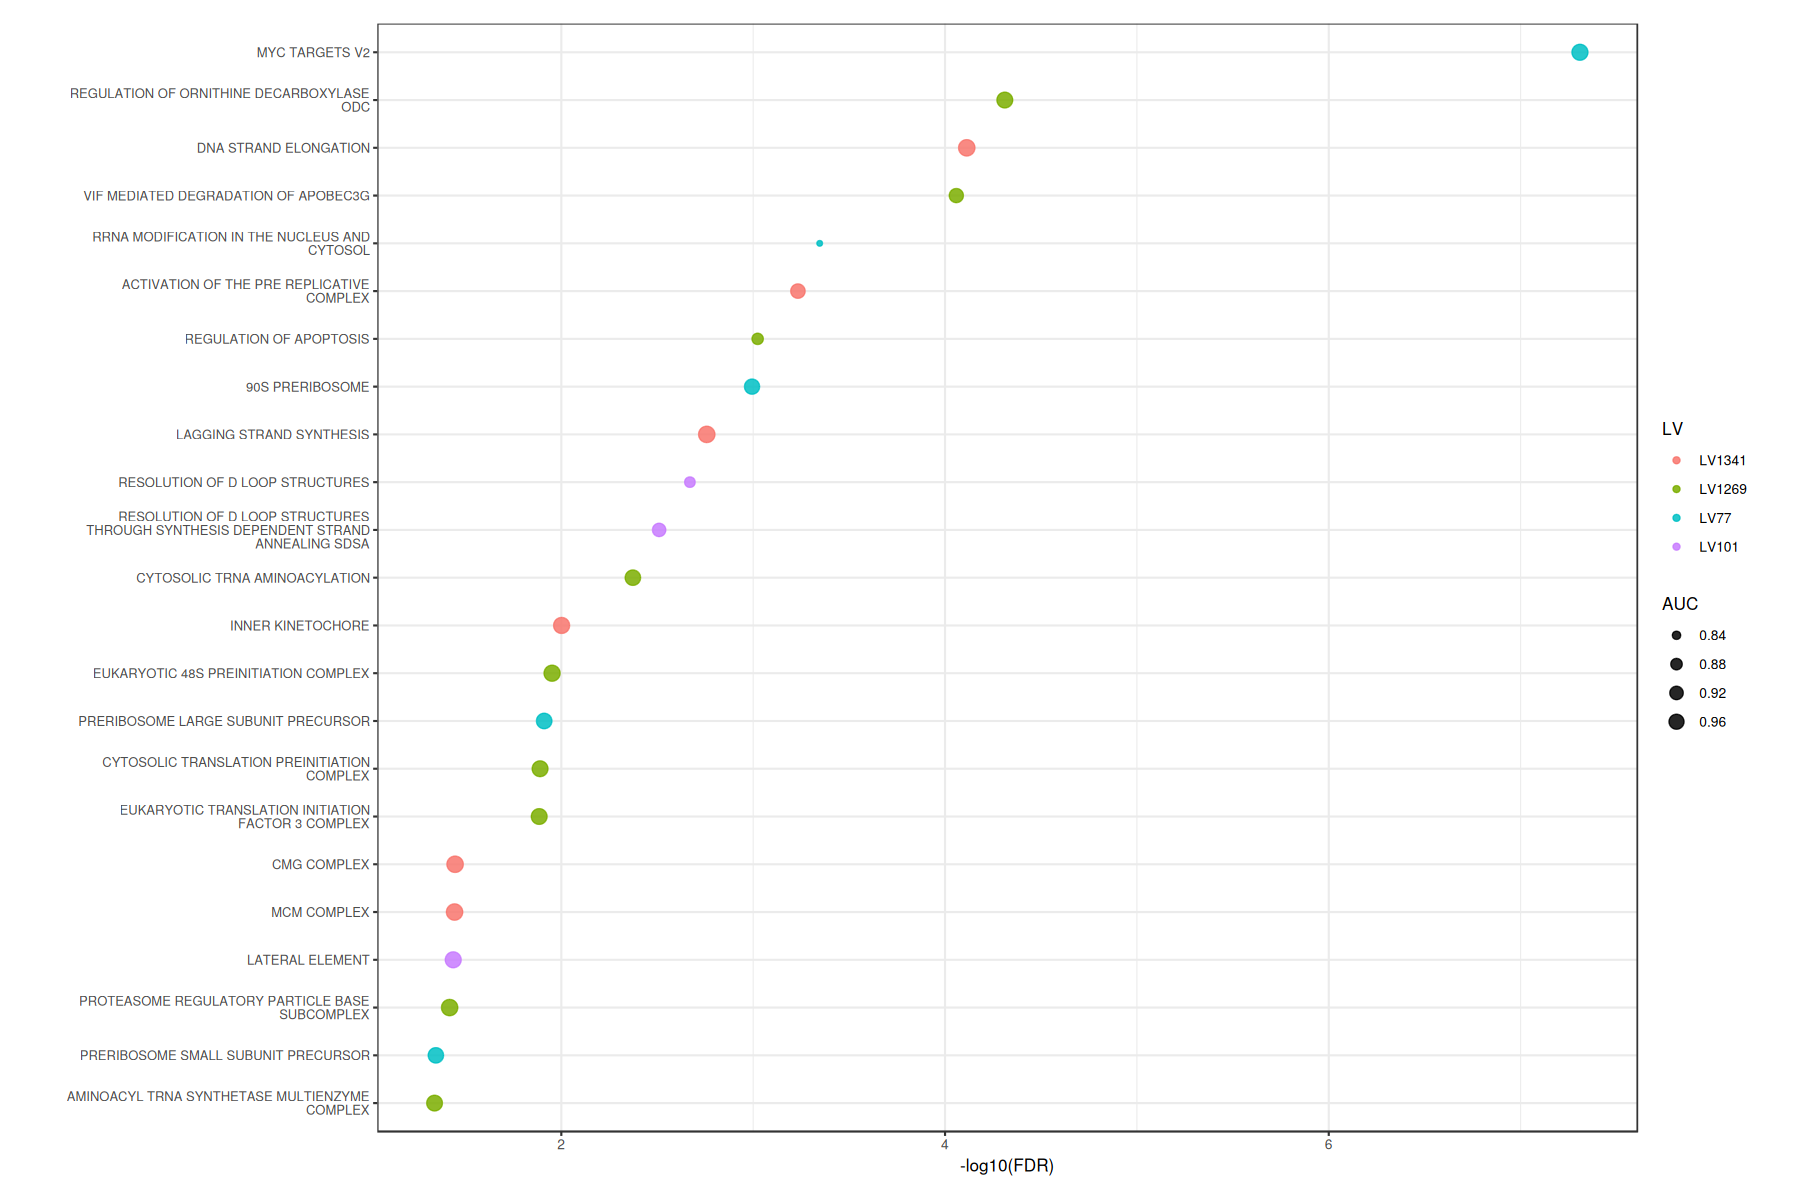

In [13]:
options(repr.plot.width = 15, repr.plot.height = 10)
print(make_pathway_dot(rank_ifn_gamma, model, direction = "down"))


## GSE133218 - IFNα vs control (all samples and pairwise per timepoint)


In [14]:
B_ifn_alpha           <- project_model(model, norm_ifn_alpha)
meta_ifn_alpha <- meta_ifn_alpha[match(colnames(B_ifn_alpha), meta_ifn_alpha$sample), ]
rank_ifn_alpha_all    <- rank_lvs(B_ifn_alpha, meta_ifn_alpha, model, contrast = c("IFNa", "Control"))
rank_ifn_alpha        <- rank_lvs_6grp(B_ifn_alpha, meta_ifn_alpha, model)

n_up_all <- sum(rank_ifn_alpha_all$adj.P.Val < 0.01 & rank_ifn_alpha_all$logFC > 0)
n_dn_all <- sum(rank_ifn_alpha_all$adj.P.Val < 0.01 & rank_ifn_alpha_all$logFC < 0)
cat("all - up:", n_up_all, "| down:", n_dn_all, "\n")

for (tp in names(rank_ifn_alpha)) {
  n_up <- sum(rank_ifn_alpha[[tp]]$adj.P.Val < 0.01 & rank_ifn_alpha[[tp]]$logFC > 0)
  n_dn <- sum(rank_ifn_alpha[[tp]]$adj.P.Val < 0.01 & rank_ifn_alpha[[tp]]$logFC < 0)
  cat(tp, "- up:", n_up, "| down:", n_dn, "\n")
}


Common genes: 12405 (67.3% of model genes)


all - up: 109 | down: 119 


2h - up: 15 | down: 11 
8h - up: 140 | down: 140 
24h - up: 92 | down: 85 


### PCA - GSE133218


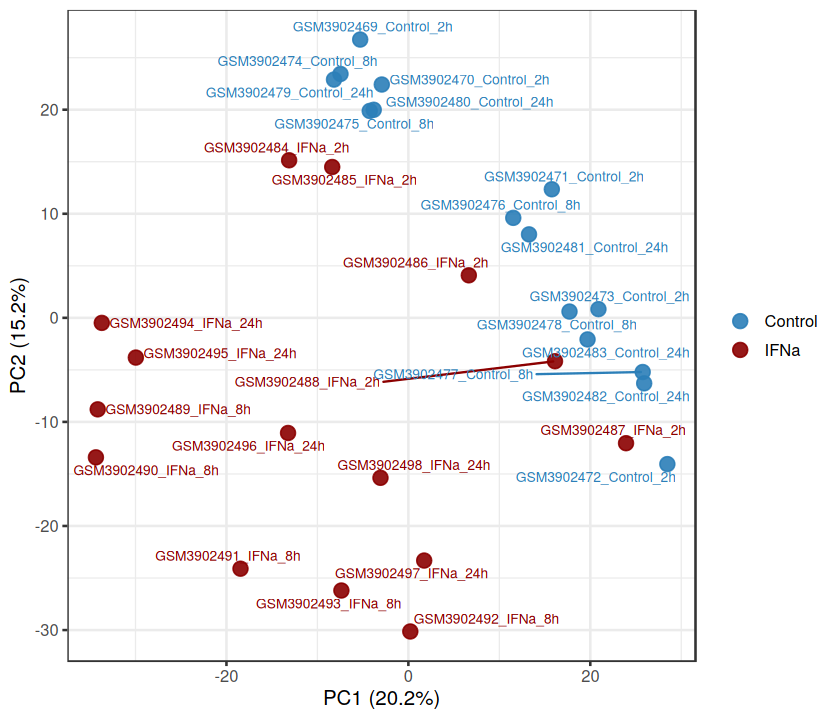

In [15]:
options(repr.plot.width = 7, repr.plot.height = 6)
print(make_pca_plot(B_ifn_alpha, meta_ifn_alpha))


### Volcano plots - GSE133218 (per timepoint)


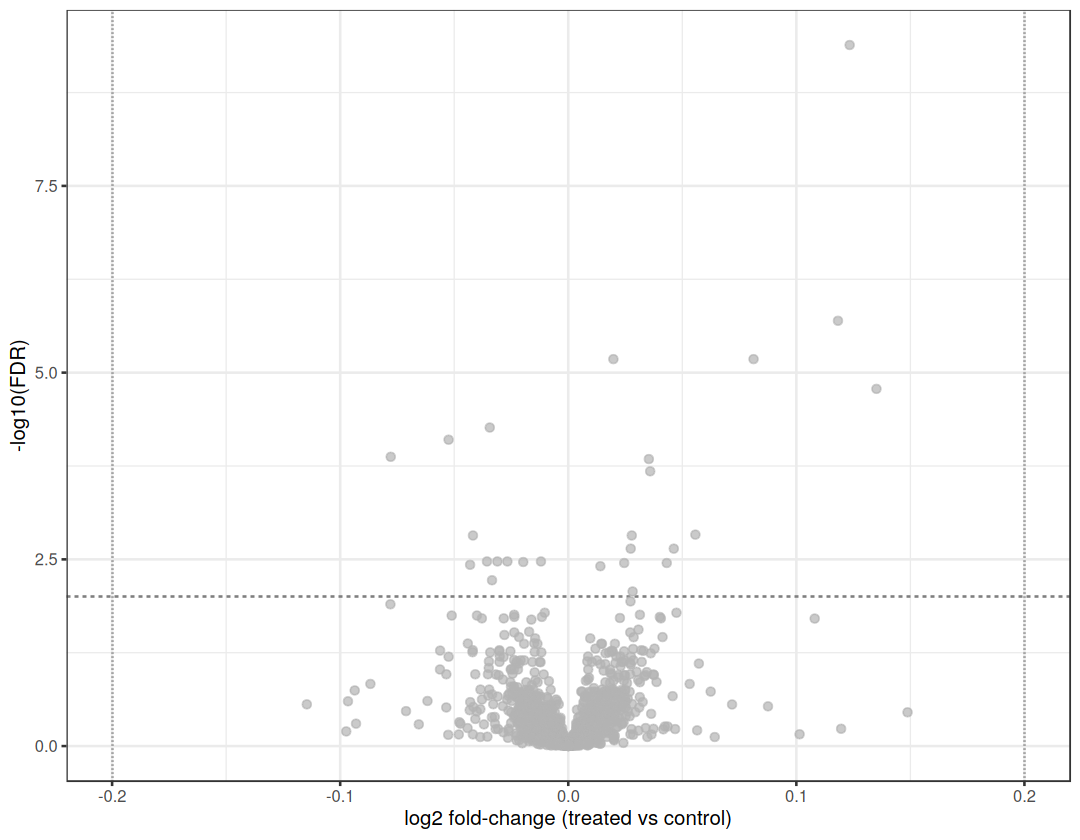

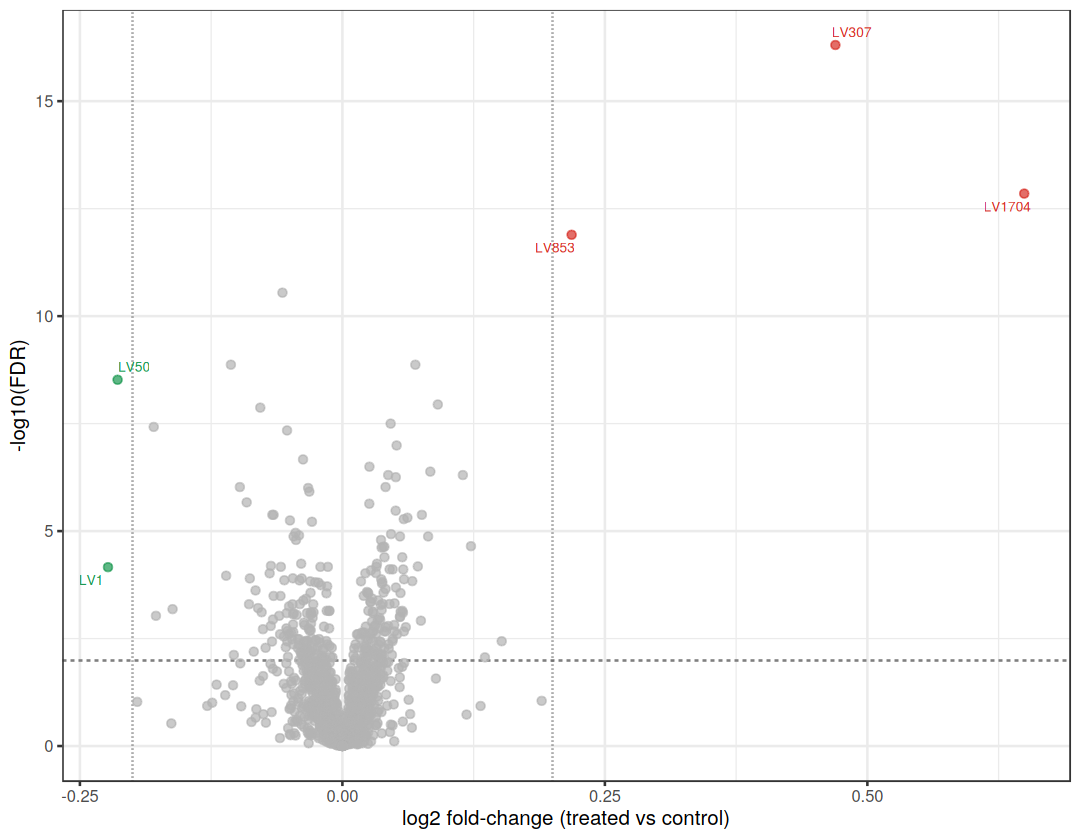

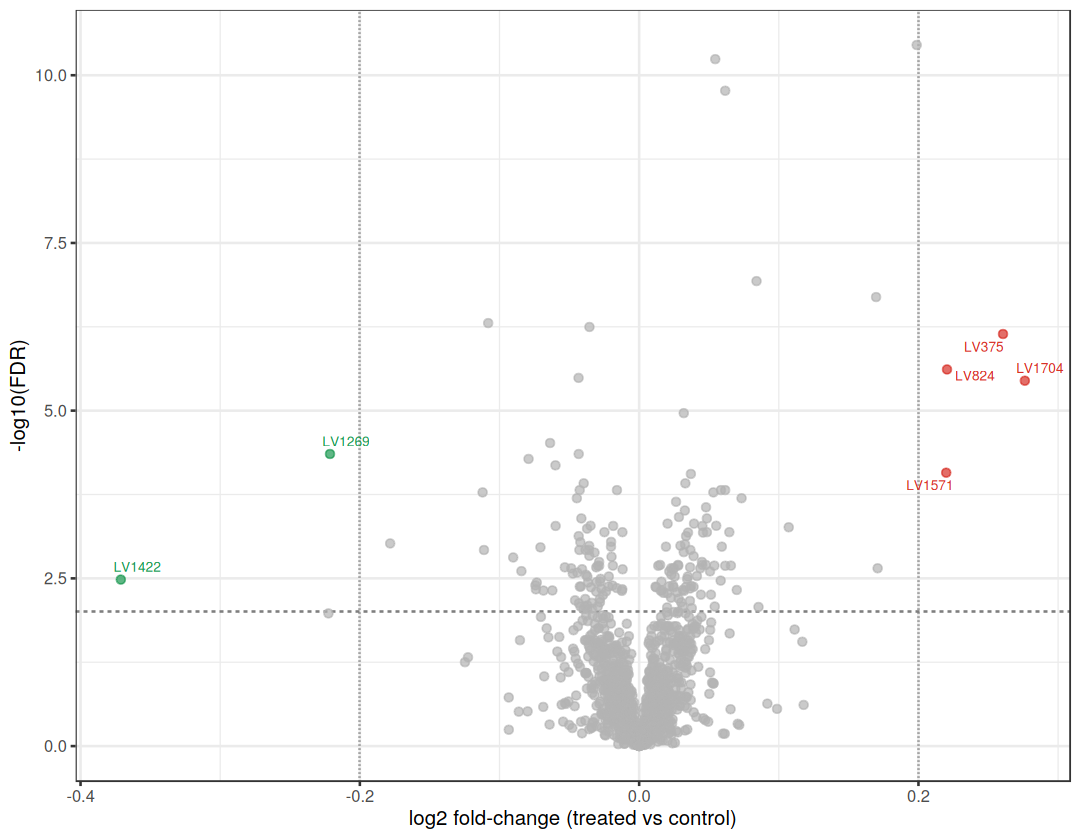

In [16]:
options(repr.plot.width = 9, repr.plot.height = 7)
for (tp in names(rank_ifn_alpha)) {
  print(make_volcano(rank_ifn_alpha[[tp]]))
}


### Signed pathway shifts - GSE133218

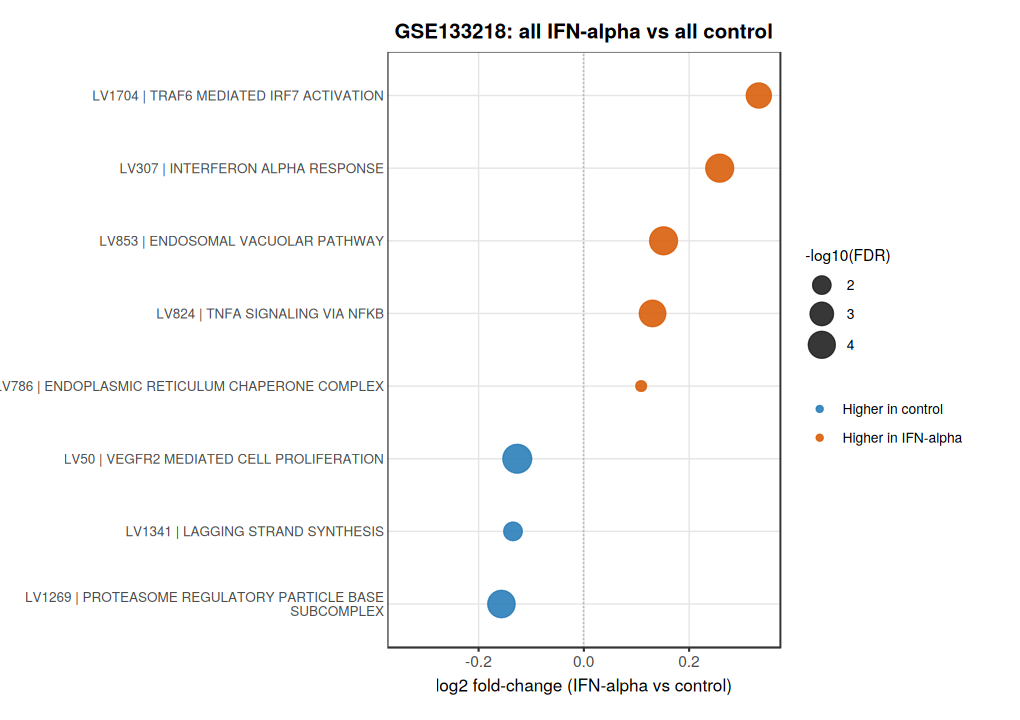

In [17]:
p_ifn_alpha_all_signed <- make_signed_pathway_shift_plot(
  rank_ifn_alpha_all,
  model,
  treated_name = "IFN-alpha",
  control_name = "control",
  title = "GSE133218: all IFN-alpha vs all control",
  fdr_cutoff = 0.05,
  lfc_cutoff = 0.1
)

options(
  repr.plot.width = attr(p_ifn_alpha_all_signed, "suggested_width"),
  repr.plot.height = attr(p_ifn_alpha_all_signed, "suggested_height")
)

print(p_ifn_alpha_all_signed)

In [18]:
rank_ifn_alpha_all  %>% 
dplyr::filter(adj.P.Val < 0.05, abs_logFC >= 0.1, pathways != "unannotated")

logFC,AveExpr,t,P.Value,adj.P.Val,B,LV,pathways,top_AUC,n_paths,abs_logFC
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>
-0.1265583,4.560154e-17,-7.159554,5.774434e-08,2.494555e-05,7.672740,LV50,VEGFR2 MEDIATED CELL PROLIFERATION,0.9137428,1,0.1265583
0.2581096,1.575996e-16,6.612237,2.556924e-07,4.909294e-05,6.171563,LV307,INTERFERON ALPHA RESPONSE | INTERFERON GAMMA RESPONSE | HE LIM SUN FETAL LUNG C2 CXCL9 POS MACROPHAGE CELL,0.9885902,3,0.2581096
0.1514581,4.348374e-17,6.528403,3.219857e-07,5.058103e-05,5.939325,LV853,ENDOSOMAL VACUOLAR PATHWAY | IRAK4 DEFICIENCY TLR2 4,1.0000000,2,0.1514581
-0.1566263,3.925679e-16,-6.202097,7.944187e-07,7.634878e-05,5.030569,LV1269,PROTEASOME REGULATORY PARTICLE BASE SUBCOMPLEX | EUKARYOTIC 48S PREINITIATION COMPLEX | CYTOSOLIC TRANSLATION PREINITIATION COMPLEX | REGULATION OF ORNITHINE DECARBOXYLASE ODC | EUKARYOTIC TRANSLATION INITIATION FACTOR 3 COMPLEX | AMINOACYL TRNA SYNTHETASE MULTIENZYME COMPLEX | CYTOSOLIC TRNA AMINOACYLATION | VIF MEDIATED DEGRADATION OF APOBEC3G | REGULATION OF APOPTOSIS,0.9982528,9,0.1566263
0.1305343,-6.013708e-17,5.761761,2.720569e-06,1.424589e-04,3.794935,LV824,TNFA SIGNALING VIA NFKB | ACTIVATION OF NF KAPPAB IN B CELLS,0.8541414,2,0.1305343
0.3324607,-3.006854e-17,5.333200,9.097499e-06,3.655925e-04,2.587418,LV1704,TRAF6 MEDIATED IRF7 ACTIVATION,0.9748345,1,0.3324607
-0.1346237,2.082969e-16,-3.560936,1.255971e-03,9.645859e-03,-2.268344,LV1341,LAGGING STRAND SYNTHESIS | CMG COMPLEX | DNA STRAND ELONGATION | MCM COMPLEX | INNER KINETOCHORE | ACTIVATION OF THE PRE REPLICATIVE COMPLEX,0.9998364,6,0.1346237
0.1088914,1.471624e-17,2.815180,8.531097e-03,3.879404e-02,-4.094362,LV786,ENDOPLASMIC RETICULUM CHAPERONE COMPLEX | OLIGOSACCHARYLTRANSFERASE COMPLEX | COPI COATED VESICLE MEMBRANE | GOLGI MEDIAL CISTERNA | IRE1ALPHA ACTIVATES CHAPERONES | HH MUTANTS ABROGATE LIGAND SECRETION,0.9987134,6,0.1088914


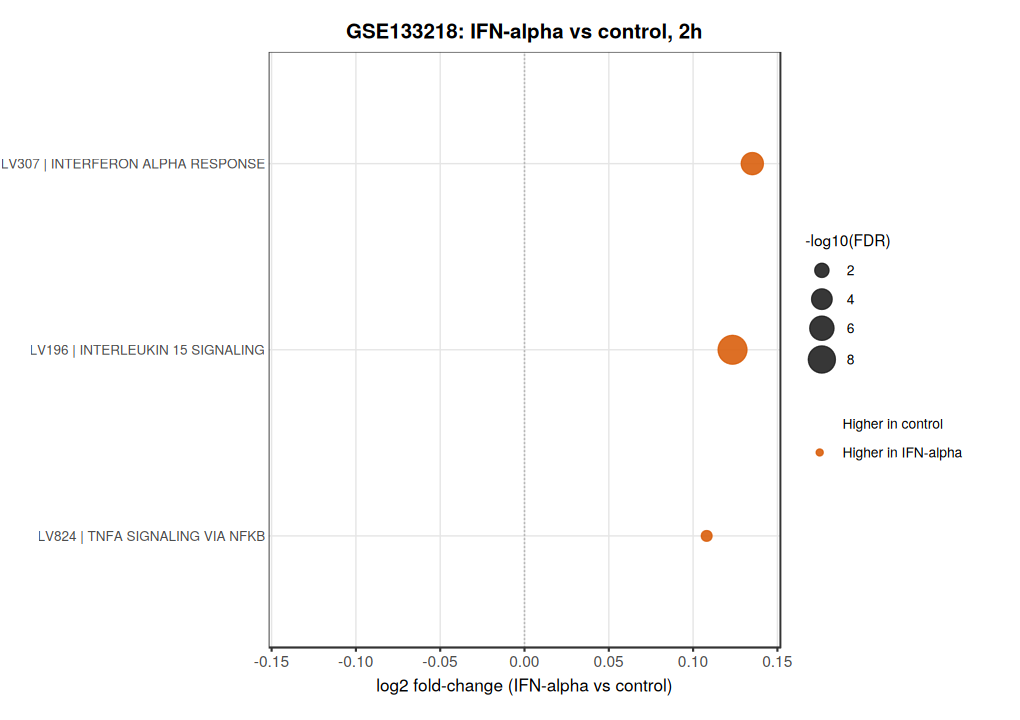

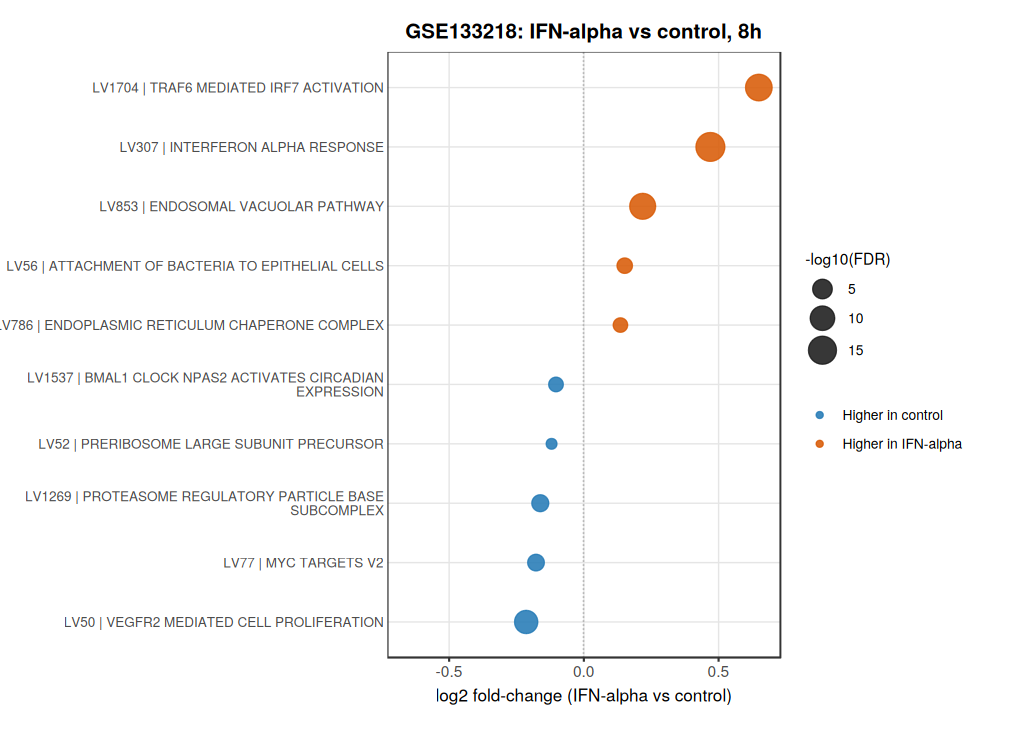

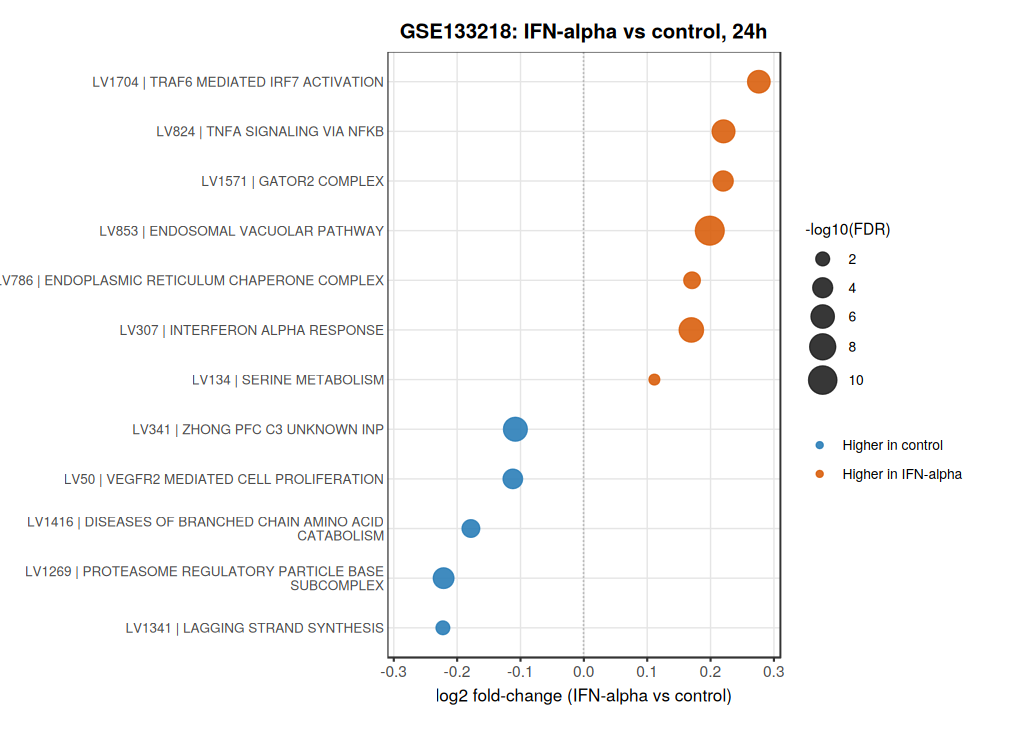

In [19]:
for (tp in names(rank_ifn_alpha)) {
  p_tp_signed <- make_signed_pathway_shift_plot(
    rank_ifn_alpha[[tp]],
    model,
    treated_name = "IFN-alpha",
    control_name = "control",
    title = paste0("GSE133218: IFN-alpha vs control, ", tp),
    fdr_cutoff = 0.05,
    lfc_cutoff = 0.1
  )

  options(
    repr.plot.width = attr(p_tp_signed, "suggested_width"),
    repr.plot.height = attr(p_tp_signed, "suggested_height")
  )

  print(p_tp_signed)
}

### Pathway dot plots - GSE133218 (per timepoint)

Top 5 up and top 5 down LVs per timepoint with all significant pathways (AUC > 0.7, FDR < 0.05).


No sig LVs



No sig LVs



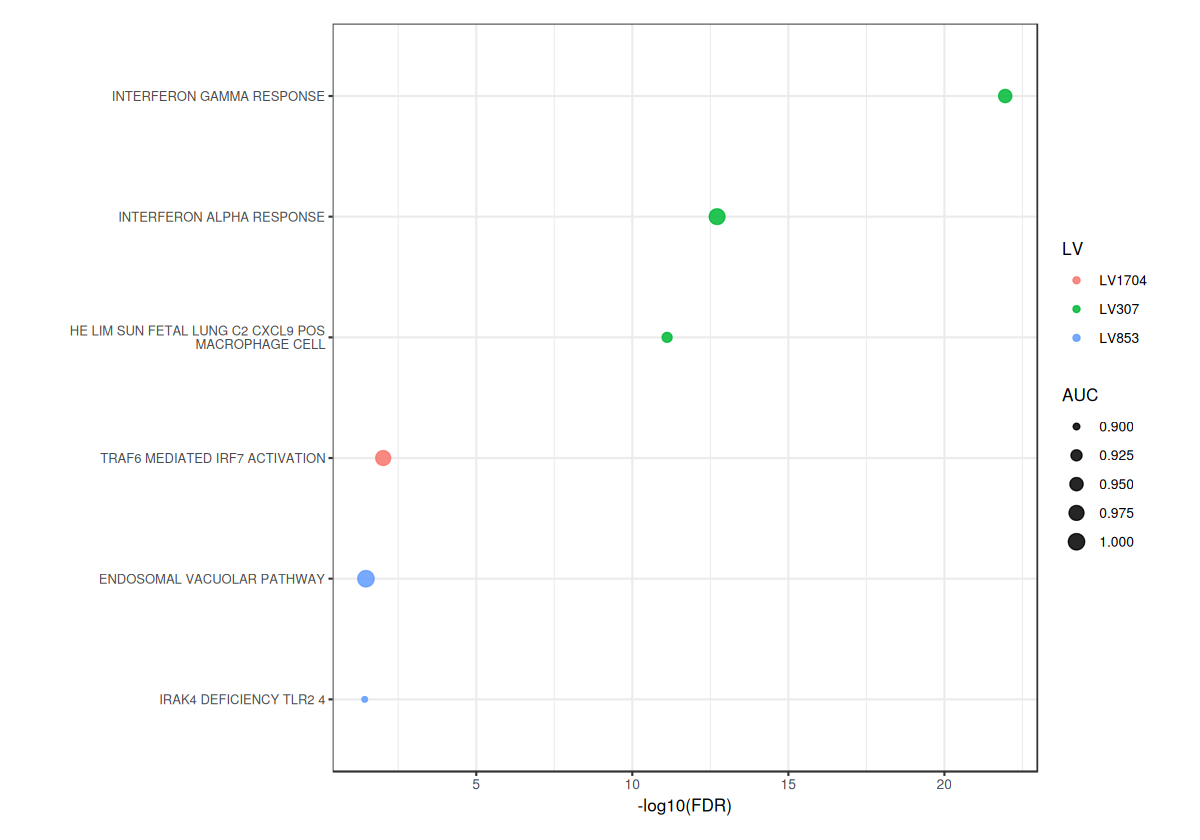

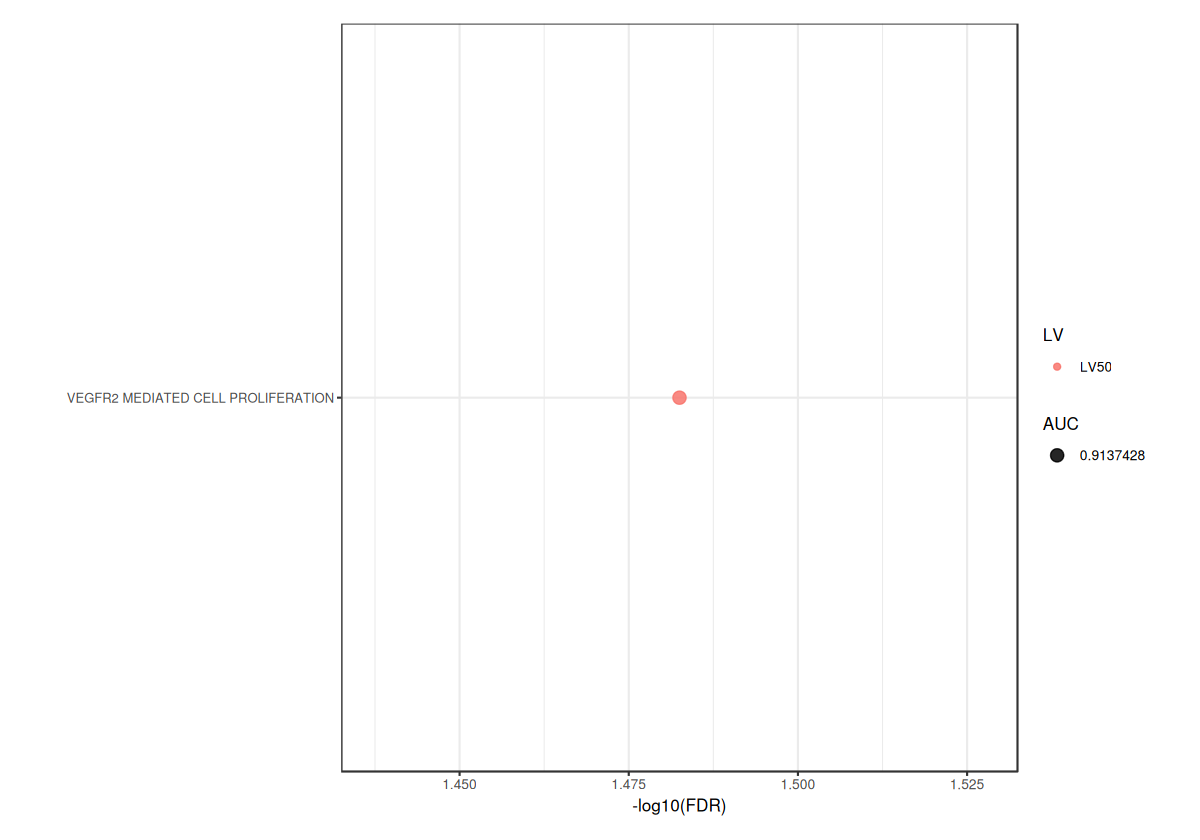

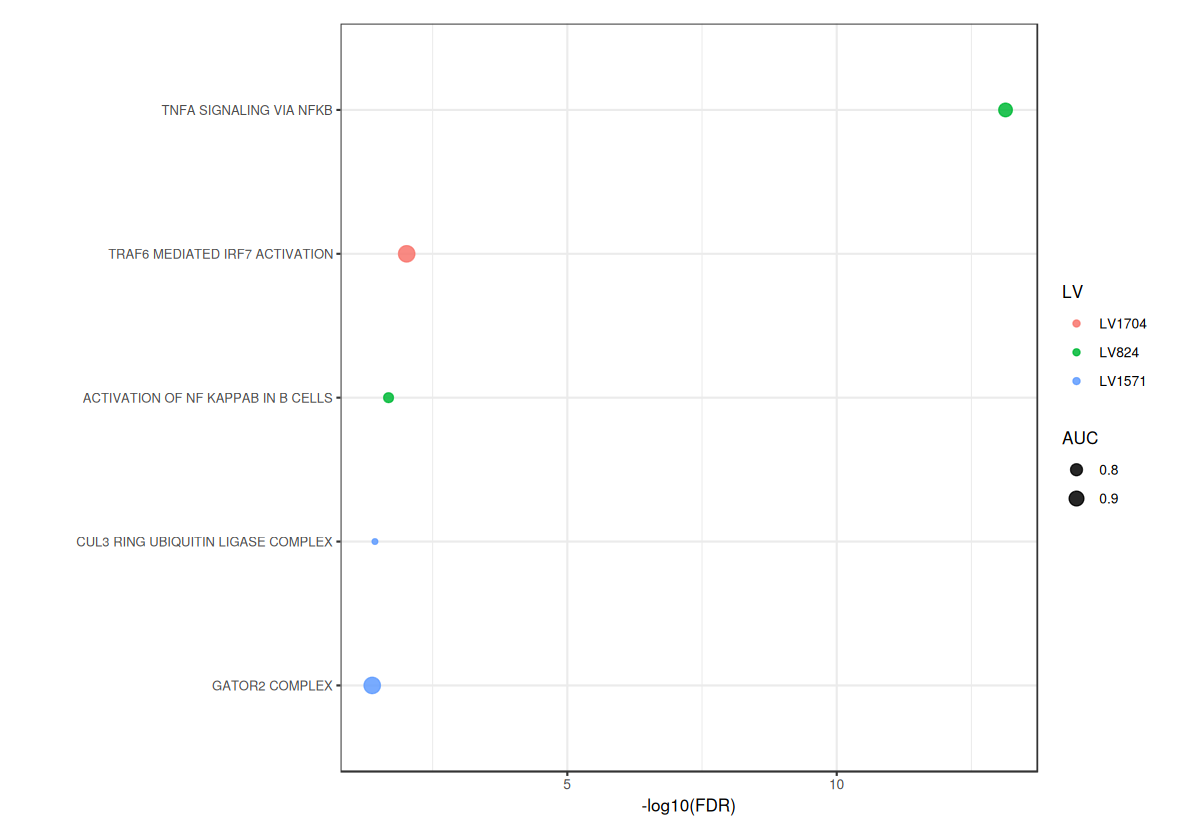

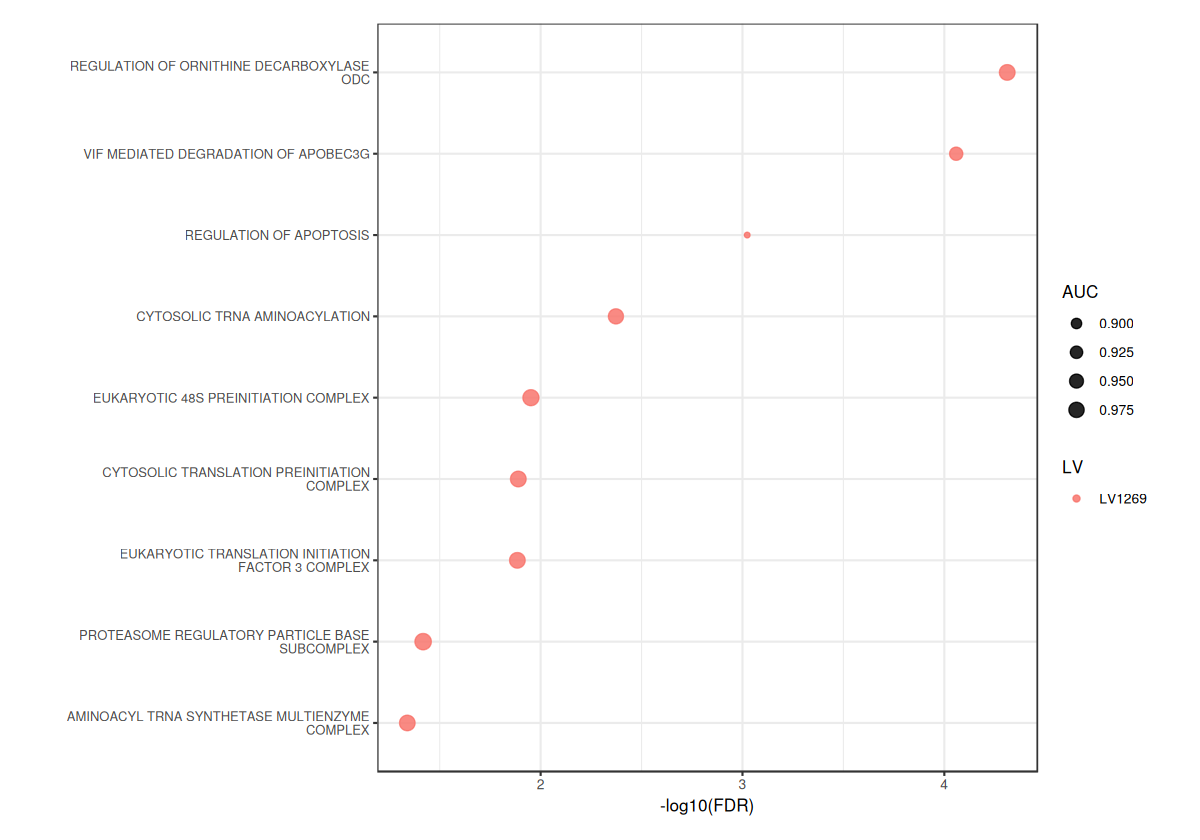

In [20]:
options(repr.plot.width = 10, repr.plot.height = 7)
for (tp in names(rank_ifn_alpha)) {
  p_up <- make_pathway_dot(rank_ifn_alpha[[tp]], model, direction = "up")
  p_dn <- make_pathway_dot(rank_ifn_alpha[[tp]], model, direction = "down")
  if (!is.null(p_up)) print(p_up)
  if (!is.null(p_dn)) print(p_dn)
}


### IFN-alpha time-course LV heatmap

Rows are differentially shifted LVs with pathway annotations passing AUC > 0.7 and annotation FDR < 0.05. All significant pathway annotations for each LV are shown.


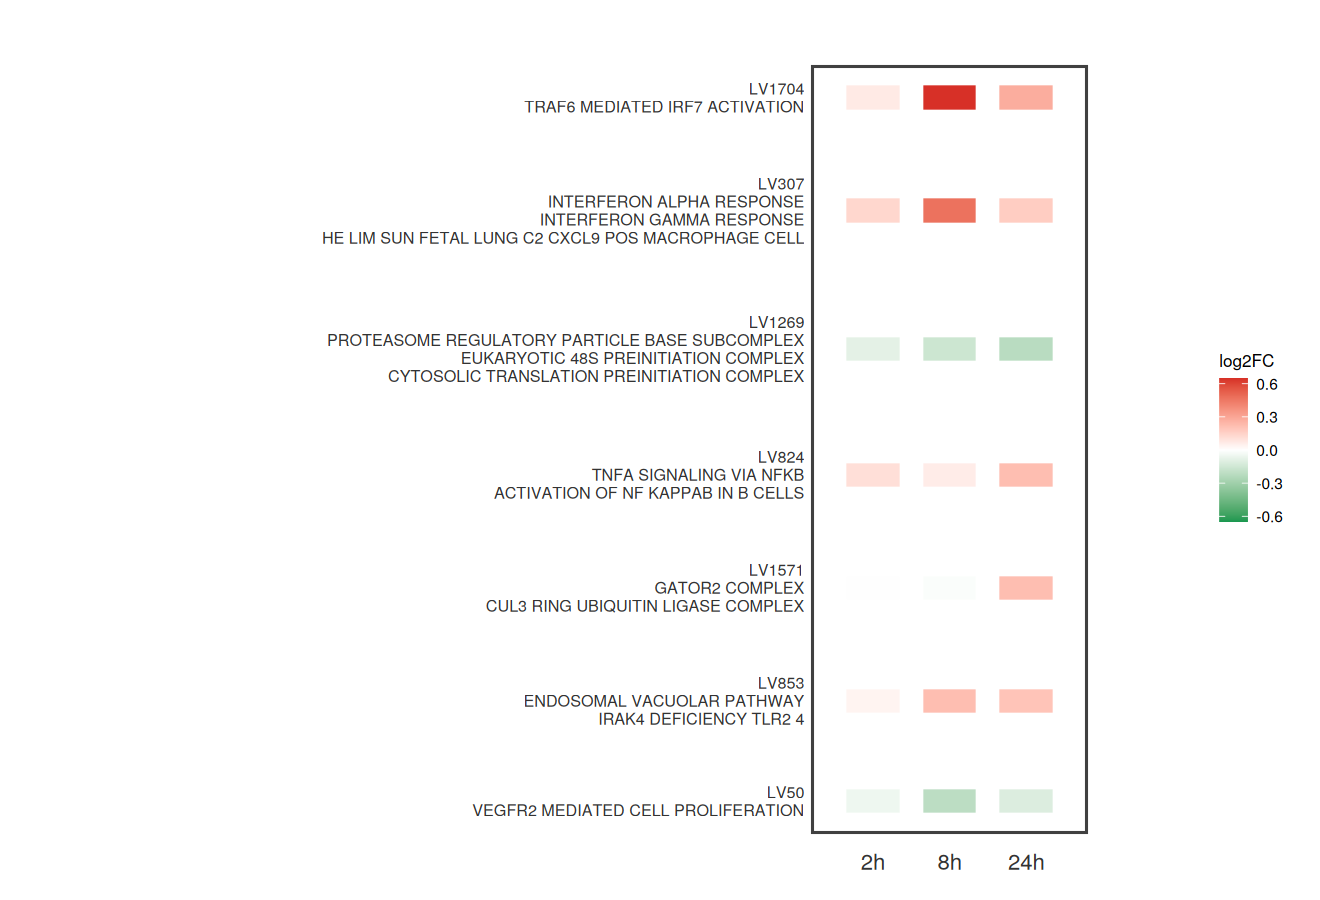

In [21]:
library(dplyr)
library(ggplot2)
library(tibble)

if (!exists("clean_pathway")) {
  clean_pathway <- function(x) {
    x <- gsub("^HALLMARK_", "", x)
    x <- gsub("^REACTOME_", "", x)
    x <- gsub("^KEGG_", "", x)
    x <- gsub("^GOBP_", "", x)
    x <- gsub("_", " ", x)
    x
  }
}

wrap_label_final <- function(x, width = 95) {
  vapply(
    x,
    function(z) paste(strwrap(z, width = width), collapse = "\n"),
    character(1)
  )
}

make_ifna_heatmap <- function(rank_133_list, mdl = model,
                              de_fdr_cutoff = 0.01,
                              lfc_cutoff = 0.2,
                              pathway_fdr_cutoff = 0.05,
                              auc_cutoff = 0.7,
                              max_lvs = 12,
                              max_paths_per_lv = 3,
                              label_width = 95,
                              label_size = 3.3,
                              timepoint_levels = c("2h", "8h", "24h")) {

  if (is.null(names(rank_133_list)) || any(names(rank_133_list) == "")) {
    names(rank_133_list) <- timepoint_levels[seq_along(rank_133_list)]
  }

  rank_133_list <- lapply(rank_133_list, function(r) {
    if (!"abs_logFC" %in% colnames(r)) {
      r <- r %>% dplyr::mutate(abs_logFC = abs(logFC))
    }
    r
  })

  annot <- mdl$summary %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::mutate(pathway = clean_pathway(pathway)) %>%
    dplyr::arrange(LV, dplyr::desc(AUC), FDR)

  annotated_lvs <- unique(annot$LV)

  sig_lvs <- unique(unlist(lapply(rank_133_list, function(r) {
    r %>%
      dplyr::filter(
        adj.P.Val < de_fdr_cutoff,
        abs_logFC >= lfc_cutoff,
        LV %in% annotated_lvs
      ) %>%
      dplyr::pull(LV)
  })))

  if (length(sig_lvs) == 0) {
    message("No annotated significant LVs")
    return(invisible(NULL))
  }

  lv_order <- dplyr::bind_rows(lapply(rank_133_list, function(r) {
    r %>%
      dplyr::filter(LV %in% sig_lvs) %>%
      dplyr::select(LV, logFC)
  })) %>%
    dplyr::group_by(LV) %>%
    dplyr::summarise(max_abs_logFC = max(abs(logFC), na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(max_abs_logFC)) %>%
    dplyr::slice_head(n = max_lvs) %>%
    dplyr::pull(LV)

  lv_annot <- annot %>%
    dplyr::filter(LV %in% lv_order) %>%
    dplyr::group_by(LV) %>%
    dplyr::slice_head(n = max_paths_per_lv) %>%
    dplyr::summarise(
      pathway_label = paste(wrap_label_final(pathway, width = label_width), collapse = "\n"),
      .groups = "drop"
    )

  lv_annot <- tibble::tibble(LV = lv_order) %>%
    dplyr::left_join(lv_annot, by = "LV") %>%
    dplyr::mutate(
      pathway_label = ifelse(is.na(pathway_label), "", pathway_label),
      lv_label = ifelse(pathway_label == "", LV, paste0(LV, "\n", pathway_label)),
      n_lines = lengths(strsplit(lv_label, "\n", fixed = TRUE)),
      row_gap = pmax(1.55, n_lines * 0.48 + 0.70),
      tile_height = 0.48
    )

  lv_annot$y_pos <- rev(cumsum(rev(lv_annot$row_gap))) - lv_annot$row_gap / 2

  x_gap <- 0.28
  tile_width <- 0.20

  label_x <- 0.95
  x_positions <- label_x + 0.25 + seq(0, by = x_gap, length.out = length(timepoint_levels))

  tp_map <- tibble::tibble(
    timepoint = timepoint_levels,
    x_pos = x_positions
  )

  hm_df <- dplyr::bind_rows(lapply(names(rank_133_list), function(tp) {
    rank_133_list[[tp]] %>%
      dplyr::filter(LV %in% lv_order) %>%
      dplyr::select(LV, logFC) %>%
      dplyr::mutate(timepoint = tp)
  })) %>%
    dplyr::inner_join(
      lv_annot %>% dplyr::select(LV, y_pos, tile_height),
      by = "LV"
    ) %>%
    dplyr::left_join(tp_map, by = "timepoint") %>%
    dplyr::filter(!is.na(x_pos))

  lim <- max(abs(hm_df$logFC), na.rm = TRUE)

  label_lines <- unlist(strsplit(lv_annot$lv_label, "\n", fixed = TRUE))
  max_label_chars <- max(nchar(label_lines), na.rm = TRUE)

  frame_xmin <- min(x_positions) - tile_width / 2 - 0.12
  frame_xmax <- max(x_positions) + tile_width / 2 + 0.12
  frame_ymin <- min(lv_annot$y_pos - lv_annot$tile_height / 2) - 0.35
  frame_ymax <- max(lv_annot$y_pos + lv_annot$tile_height / 2) + 0.35

  x_left <- label_x - max(2.8, max_label_chars * 0.045)
  x_right <- frame_xmax + 0.45

  p <- ggplot() +
    annotate(
      "rect",
      xmin = frame_xmin,
      xmax = frame_xmax,
      ymin = frame_ymin,
      ymax = frame_ymax,
      fill = NA,
      colour = "grey25",
      linewidth = 0.65
    ) +
    geom_tile(
      data = hm_df,
      aes(x = x_pos, y = y_pos, fill = logFC, height = tile_height),
      width = tile_width,
      color = "white",
      linewidth = 0.35
    ) +
    geom_text(
      data = lv_annot,
      aes(x = label_x, y = y_pos, label = lv_label),
      hjust = 1,
      vjust = 0.5,
      size = label_size,
      lineheight = 0.96,
      color = "grey20"
    ) +
    scale_fill_gradient2(
      low = "#1a9850",
      mid = "white",
      high = "#d73027",
      midpoint = 0,
      limits = c(-lim, lim),
      name = "log2FC"
    ) +
    scale_x_continuous(
      breaks = x_positions,
      labels = timepoint_levels,
      limits = c(x_left, x_right),
      expand = c(0, 0)
    ) +
    scale_y_continuous(
      limits = c(0, max(lv_annot$y_pos) + max(lv_annot$row_gap) / 2),
      expand = c(0, 0)
    ) +
    labs(x = NULL, y = NULL) +
    coord_cartesian(clip = "off") +
    theme_void(base_size = 10) +
    theme(
      axis.text.x = element_text(size = 13, color = "grey20", margin = margin(t = 4)),
      axis.ticks.x = element_blank(),
      legend.position = "right",
      legend.title = element_text(size = 10),
      legend.text = element_text(size = 9),
      plot.margin = margin(6, 8, 6, 8, "mm")
    )

  attr(p, "suggested_width") <- max(11, 6.5 + max_label_chars * 0.045)
  attr(p, "suggested_height") <- max(7.5, sum(lv_annot$row_gap) * 0.46)

  p
}

p <- make_ifna_heatmap(
  rank_133_list = rank_ifn_alpha,
  mdl = model,
  de_fdr_cutoff = 0.01,
  lfc_cutoff = 0.2,
  pathway_fdr_cutoff = 0.05,
  auc_cutoff = 0.7,
  max_lvs = 12,
  max_paths_per_lv = 3,
  label_width = 95,
  label_size = 3.3
)

options(
  repr.plot.width = attr(p, "suggested_width"),
  repr.plot.height = attr(p, "suggested_height")
)

print(p)

## Build local CLAMP models

Train a CLAMP model directly on each dataset using the same pathway prior as the ARCHS4 model (Hallmark, Reactome, GO-CC, C8). Because both datasets are small (10 and 30 samples), K is set to `n_samples − 1` to use all available dimensions. Models are cached to disk after the first run.

In [22]:
suppressPackageStartupMessages({
  library(bigstatsr)
  library(rsvd)
  library(PCAtools)
})

pathways_path <- here("data", "pathways")
hall_gmt     <- CLAMP:::read_gmt(file.path(pathways_path, "h.all.v2026.1.Hs.symbols.gmt"))
reactome_gmt <- CLAMP:::read_gmt(file.path(pathways_path, "c2.cp.reactome.v2026.1.Hs.symbols.gmt"))
gocc_gmt     <- CLAMP:::read_gmt(file.path(pathways_path, "c5.go.cc.v2026.1.Hs.symbols.gmt"))
c8_gmt       <- CLAMP:::read_gmt(file.path(pathways_path, "c8.all.v2026.1.Hs.symbols.gmt"))

names(hall_gmt)     <- paste0("HALL_",     names(hall_gmt))
names(reactome_gmt) <- paste0("REACTOME_", names(reactome_gmt))
names(gocc_gmt)     <- paste0("GOCC_",     names(gocc_gmt))
names(c8_gmt)       <- paste0("C8_",       names(c8_gmt))

all_pathways_list <- list(
  HALL = hall_gmt, REACTOME = reactome_gmt, GOCC = gocc_gmt, C8 = c8_gmt
)
all_pathways_pathMat <- gmtListToSparseMat(all_pathways_list)
cat("Loaded pathway prior matrix:",
    nrow(all_pathways_pathMat), "genes x", ncol(all_pathways_pathMat), "pathways\n")


Loaded pathway prior matrix: 23726 genes x 3835 pathways


In [23]:
build_local_clamp <- function(norm_mat, dataset_name, out_dir,
                               pathways_pathMat, max_iter = 200) {
  rds_path <- file.path(out_dir, paste0(dataset_name, "_CLAMPfull.rds"))
  if (file.exists(rds_path)) {
    message("Loading cached local CLAMP model: ", dataset_name)
    return(readRDS(rds_path))
  }

  genes     <- rownames(norm_mat)
  samples   <- colnames(norm_mat)
  n_genes   <- nrow(norm_mat)
  n_samples <- ncol(norm_mat)

  # Wrap in FBM (CLAMPbase / CLAMPfull require FBM input)
  fbm_path <- file.path(out_dir, paste0(dataset_name, "_local_fbm"))
  on.exit({
    try(unlink(paste0(fbm_path, ".bk")), silent = TRUE)
    try(unlink(paste0(fbm_path, ".rds")), silent = TRUE)
  }, add = TRUE)
  fbm      <- FBM(n_genes, n_samples, backingfile = fbm_path, create_bk = TRUE)
  fbm[]    <- norm_mat

  # SVD: use all available dimensions for small datasets
  SVD_K   <- min(n_genes, n_samples) - 1
  svd_res <- rsvd(norm_mat, k = SVD_K)
  CLAMP_K <- SVD_K
  message("Dataset: ", dataset_name,
          " | n_genes=", n_genes, " | n_samples=", n_samples, " | K=", CLAMP_K)

  # CLAMPbase
  base_res <- CLAMPbase(Y = fbm, svdres = svd_res, trace = TRUE, clamp_k = CLAMP_K)
  base_res$Z <- data.frame(base_res$Z)
  rownames(base_res$Z) <- genes

  # Match pathway priors to dataset genes
  matched <- getMatchedPathwayMat(pathways_pathMat, genes)

  # CLAMPfull
  full_res <- CLAMPfull(
    Y                 = fbm,
    svdres            = svd_res,
    priorMat          = matched,
    clamp.base.result = base_res,
    use_cpp           = TRUE,
    trace             = TRUE,
    max.iter          = max_iter,
    clamp_k           = CLAMP_K
  )

  full_res$Z <- data.frame(full_res$Z)
  rownames(full_res$Z) <- genes
  full_res$B <- data.frame(full_res$B)
  colnames(full_res$B) <- samples
  full_res$summary <- full_res$summary %>%
    dplyr::rename(LV = LV_index) %>%
    dplyr::mutate(LV = paste0("LV", LV))

  saveRDS(full_res, rds_path)
  message("Saved local CLAMP model: ", rds_path)
  full_res
}


### IFN-γ (GSE137136) local model

In [24]:
model_ifn_gamma <- build_local_clamp(
  norm_mat         = norm_ifn_gamma,
  dataset_name     = "ifn_gamma",
  out_dir          = data_dir,
  pathways_pathMat = all_pathways_pathMat
)

n_sig_ifn_gamma <- sum(model_ifn_gamma$summary$FDR < 0.05 &
                        model_ifn_gamma$summary$AUC > 0.7, na.rm = TRUE)
cat("IFN-gamma local model | LVs:", ncol(model_ifn_gamma$Z),
    "| pathway-LV annotations (AUC>0.7, FDR<0.05):", n_sig_ifn_gamma, "\n")
print(head(model_ifn_gamma$summary %>% dplyr::filter(FDR < 0.05, AUC > 0.7) %>%
             dplyr::arrange(dplyr::desc(AUC))))


Dataset: ifn_gamma | n_genes=13066 | n_samples=10 | K=9



****



CLAMP k is set to 9



L1 is set to 10.1278213118737



L2 is set to 30.3834639356212



...

There are 9 LVs with AUC>0.70



There are 6 LVs with AUC>0.90



Saved local CLAMP model: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/02_pro_inflammatory_cytokines/data/ifn_gamma_CLAMPfull.rds



IFN-gamma local model | LVs: 9 | pathway-LV annotations (AUC>0.7, FDR<0.05): 9 


                                                        pathway  LV       AUC
C8849                               C8_ZHONG_PFC_C3_UNKNOWN_INP LV1 0.9762795
REACTOME495 REACTOME_REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION LV5 0.9516566
HALL26                  HALL_HALLMARK_INTERFERON_ALPHA_RESPONSE LV9 0.9032185
GOCC698                             GOCC_GOCC_OUTER_KINETOCHORE LV1 0.9009504
C8844                               C8_ZHONG_PFC_C2_UNKNOWN_NPC LV1 0.8951301
GOCC258             GOCC_GOCC_CYTOSOLIC_LARGE_RIBOSOMAL_SUBUNIT LV5 0.8808277
                 p_value          FDR npos  nneg
C8849       1.380739e-05 1.380739e-04    6 12837
REACTOME495 1.095871e-11 8.766965e-10   17 12904
HALL26      3.570121e-11 1.428048e-09   17 12909
GOCC698     1.976721e-03 1.757085e-02    4 12837
C8844       5.459074e-08 8.233898e-07   14 12837
GOCC258     7.472892e-06 8.540448e-05   10 12904


### IFN-α (GSE133218) local model

In [25]:
model_ifn_alpha <- build_local_clamp(
  norm_mat         = norm_ifn_alpha,
  dataset_name     = "ifn_alpha",
  out_dir          = file.path(data_dir, "GSE133218"),
  pathways_pathMat = all_pathways_pathMat
)

n_sig_ifn_alpha <- sum(model_ifn_alpha$summary$FDR < 0.05 &
                        model_ifn_alpha$summary$AUC > 0.7, na.rm = TRUE)
cat("IFN-alpha local model | LVs:", ncol(model_ifn_alpha$Z),
    "| pathway-LV annotations (AUC>0.7, FDR<0.05):", n_sig_ifn_alpha, "\n")
print(head(model_ifn_alpha$summary %>% dplyr::filter(FDR < 0.05, AUC > 0.7) %>%
             dplyr::arrange(dplyr::desc(AUC))))


Dataset: ifn_alpha | n_genes=13232 | n_samples=30 | K=29



****



CLAMP k is set to 29



L1 is set to 12.2045375623004



L2 is set to 36.6136126869011



...

There are 27 LVs with AUC>0.70



There are 13 LVs with AUC>0.90



Saved local CLAMP model: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/02_pro_inflammatory_cytokines/data/GSE133218/ifn_alpha_CLAMPfull.rds



IFN-alpha local model | LVs: 29 | pathway-LV annotations (AUC>0.7, FDR<0.05): 44 


                                                                              pathway
GOCC789                                 GOCC_GOCC_PRERIBOSOME_LARGE_SUBUNIT_PRECURSOR
REACTOME2301 REACTOME_REACTOME_CHOLESTEROL_BIOSYNTHESIS_VIA_DESMOSTEROL_BLOCH_PATHWAY
REACTOME1429        REACTOME_REACTOME_SARS_COV_1_MODULATES_HOST_TRANSLATION_MACHINERY
REACTOME1003                  REACTOME_REACTOME_NON_CANONICAL_INFLAMMASOME_ACTIVATION
REACTOME1799                                       REACTOME_REACTOME_UNWINDING_OF_DNA
GOCC2                                                       GOCC_GOCC_90S_PRERIBOSOME
               LV       AUC      p_value          FDR npos  nneg
GOCC789       LV7 1.0000000 5.334817e-04 5.654906e-03    3 13063
REACTOME2301 LV24 1.0000000 3.482155e-03 2.796276e-02    2 13143
REACTOME1429 LV28 1.0000000 2.130345e-07 4.282936e-06    7 13057
REACTOME1003 LV23 0.9994983 2.180092e-03 1.925748e-02    2 12956
REACTOME1799  LV1 0.9993414 4.624041e-03 3.323165e-02    2 12907
GOCC2   

## DESeq2 differential expression

Standard DEG approach (DESeq2) applied separately on each dataset, followed by GSEA with the same pathway sets used in CLAMP. Results are compared to the CLAMP projection and local models to assess how much biology a conventional pipeline recovers versus the LV-based approach.

In [26]:
suppressPackageStartupMessages({
  library(DESeq2)
  library(fgsea)
})

# Flatten pathway list for fgsea (same sets as CLAMP model)
pathways_fgsea <- c(
  all_pathways_list$HALL,
  all_pathways_list$REACTOME,
  all_pathways_list$GOCC,
  all_pathways_list$C8
)

run_deseq2 <- function(counts_mat, col_df,
                        contrast = c("condition", "trt", "ctrl")) {
  dds <- DESeqDataSetFromMatrix(
    countData = round(counts_mat),
    colData   = col_df,
    design    = ~ condition
  )
  dds <- dds[rowSums(counts(dds) >= 5) >= 3, ]
  dds <- DESeq(dds, quiet = TRUE)
  res <- results(dds, contrast = contrast, alpha = 0.05)
  as.data.frame(res) %>%
    tibble::rownames_to_column("gene") %>%
    dplyr::filter(!is.na(stat)) %>%
    dplyr::arrange(dplyr::desc(stat))
}

run_gsea <- function(de_df, pathways,
                      min_size = 15, max_size = 500, n_perm = 1000, seed = 42) {
  ranks <- setNames(de_df$stat, de_df$gene)
  set.seed(seed)
  fgsea(pathways    = pathways,
        stats       = ranks,
        minSize     = min_size,
        maxSize     = max_size,
        nPermSimple = n_perm)
}

make_gene_volcano <- function(de_df, fdr_cutoff = 0.05, lfc_cutoff = 1,
                               label_top = 20, title = NULL) {
  df <- de_df %>%
    dplyr::filter(!is.na(padj)) %>%
    dplyr::mutate(
      dir = dplyr::case_when(
        padj < fdr_cutoff & log2FoldChange >= lfc_cutoff  ~ "up",
        padj < fdr_cutoff & log2FoldChange <= -lfc_cutoff ~ "down",
        TRUE ~ "ns"
      ),
      neg_log10 = pmin(-log10(padj), 60)
    )
  top_ids <- df %>%
    dplyr::filter(dir != "ns") %>%
    dplyr::arrange(dplyr::desc(abs(log2FoldChange))) %>%
    dplyr::slice_head(n = label_top) %>%
    dplyr::pull(gene)
  df <- df %>% dplyr::mutate(label = dplyr::if_else(gene %in% top_ids, gene, NA_character_))
  ggplot(df, aes(log2FoldChange, neg_log10, color = dir)) +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "grey50") +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dotted", color = "grey40") +
    geom_point(alpha = 0.6, size = 1.5) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.6, max.overlaps = 20,
                              show.legend = FALSE, na.rm = TRUE) +
    scale_color_manual(values = c(up = "#d73027", down = "#1a9850", ns = "grey70"),
                       guide = "none") +
    labs(x = "log2 fold-change (treated vs control)", y = "-log10(FDR)",
         title = title) +
    theme_bw(base_size = 12)
}

make_gsea_shift_plot <- function(gsea_dt, fdr_cutoff = 0.05, nes_cutoff = 0.5,
                                  top_n = 10, treated_name = "treated",
                                  control_name = "control", title = NULL) {
  direction_levels <- c(paste0("Higher in ", control_name),
                        paste0("Higher in ", treated_name))
  df <- as.data.frame(gsea_dt) %>%
    dplyr::filter(!is.na(padj), padj < fdr_cutoff, abs(NES) >= nes_cutoff) %>%
    dplyr::mutate(
      pathway_clean = clean_pathway(pathway),
      direction = factor(
        dplyr::if_else(NES > 0,
          paste0("Higher in ", treated_name),
          paste0("Higher in ", control_name)),
        levels = direction_levels),
      neg_log10_fdr = -log10(pmax(padj, .Machine$double.xmin))
    ) %>%
    dplyr::group_by(direction) %>%
    dplyr::arrange(dplyr::desc(abs(NES)), .by_group = TRUE) %>%
    dplyr::slice_head(n = top_n) %>%
    dplyr::ungroup() %>%
    dplyr::arrange(dplyr::desc(NES)) %>%
    dplyr::mutate(
      row_label = wrap_label(pathway_clean, width = 55),
      row_label = factor(row_label, levels = rev(unique(row_label)))
    )
  if (nrow(df) == 0) { message("No significant pathways"); return(invisible(NULL)) }
  x_lim <- max(abs(df$NES), na.rm = TRUE) * 1.08
  ggplot(df, aes(x = NES, y = row_label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55", linewidth = 0.35) +
    geom_point(aes(size = neg_log10_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(values = setNames(c("#2C7FB8", "#D95F0E"), direction_levels),
                        drop = FALSE, name = NULL) +
    scale_size_continuous(range = c(2.4, 7.5), name = "-log10(FDR)",
                          guide = guide_legend(override.aes = list(colour = "#222222"))) +
    scale_x_continuous(limits = c(-x_lim, x_lim), expand = expansion(mult = 0.02)) +
    labs(title = title,
         x = paste0("NES (", treated_name, " vs ", control_name, ")"), y = NULL) +
    theme_bw(base_size = 10) +
    theme(plot.title   = element_text(size = 12, face = "bold", hjust = 0.5),
          axis.text.y  = element_text(size = 7.8, colour = "grey30"),
          axis.text.x  = element_text(size = 9),
          legend.position = "right",
          plot.margin  = margin(5, 10, 5, 5, "mm"))
}

make_gsea_vs_clamp_plot <- function(gsea_dt, de_clamp, mdl_clamp,
                                     title = "GSEA vs CLAMP comparison") {
  pw_clamp <- aggregate_to_pathway(de_clamp, mdl_clamp) %>%
    dplyr::select(pathway_clean, logFC, adj.P.Val) %>%
    dplyr::rename(lfc_clamp = logFC, fdr_clamp = adj.P.Val)
  pw_gsea <- as.data.frame(gsea_dt) %>%
    dplyr::mutate(pathway_clean = clean_pathway(pathway)) %>%
    dplyr::select(pathway_clean, NES, padj) %>%
    dplyr::rename(nes_gsea = NES, fdr_gsea = padj)
  comp <- dplyr::inner_join(pw_clamp, pw_gsea, by = "pathway_clean") %>%
    dplyr::mutate(
      sig_both = fdr_clamp < 0.05 & !is.na(fdr_gsea) & fdr_gsea < 0.05,
      label    = dplyr::if_else(sig_both, pathway_clean, NA_character_)
    )
  if (nrow(comp) < 2) {
    message("Not enough shared annotated pathways (n = ", nrow(comp), ")")
    return(invisible(NULL))
  }
  cor_val <- cor(comp$lfc_clamp, comp$nes_gsea, method = "spearman", use = "complete.obs")
  ggplot(comp, aes(x = nes_gsea, y = lfc_clamp)) +
    geom_hline(yintercept = 0, linetype = "dashed", colour = "grey60") +
    geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
    geom_point(aes(colour = sig_both, size = -log10(pmax(fdr_gsea, 1e-300))), alpha = 0.75) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.5, max.overlaps = 20,
                              na.rm = TRUE, show.legend = FALSE) +
    scale_colour_manual(values = c("FALSE" = "grey70", "TRUE" = "#d73027"),
                        name = "FDR<0.05\nboth") +
    scale_size_continuous(range = c(1.2, 5), name = "-log10(FDR)\nGSEA") +
    labs(x = "NES (DESeq2 + GSEA)", y = "log2FC (CLAMP)",
         title = paste0(title, "  |  Spearman r = ", round(cor_val, 3),
                        "  |  n = ", nrow(comp))) +
    theme_bw(base_size = 12)
}

# ── pathway-level helpers used by both DESeq2 and local-CLAMP comparisons ─
aggregate_to_pathway <- function(de_result, mdl, pw_fdr = 0.05, auc_cut = 0.7) {
  annot <- mdl$summary %>%
    dplyr::filter(FDR < pw_fdr, AUC > auc_cut) %>%
    dplyr::select(LV, pathway, AUC)
  de_result %>%
    dplyr::select(LV, logFC, adj.P.Val) %>%
    dplyr::inner_join(annot, by = "LV") %>%
    dplyr::mutate(pathway_clean = clean_pathway(pathway)) %>%
    dplyr::group_by(pathway_clean) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs(logFC)), .by_group = TRUE) %>%
    dplyr::slice(1) %>%
    dplyr::ungroup()
}

make_comparison_plot <- function(de_proj, de_local, mdl_proj, mdl_local,
                                  title = "Pathway comparison") {
  pw_p <- aggregate_to_pathway(de_proj,  mdl_proj) %>%
    dplyr::select(pathway_clean, logFC, adj.P.Val) %>%
    dplyr::rename(lfc_proj = logFC, fdr_proj = adj.P.Val)
  pw_l <- aggregate_to_pathway(de_local, mdl_local) %>%
    dplyr::select(pathway_clean, logFC, adj.P.Val) %>%
    dplyr::rename(lfc_local = logFC, fdr_local = adj.P.Val)
  comp <- dplyr::inner_join(pw_p, pw_l, by = "pathway_clean") %>%
    dplyr::mutate(
      sig_both = fdr_proj < 0.05 & fdr_local < 0.05,
      label    = dplyr::if_else(sig_both, pathway_clean, NA_character_)
    )
  if (nrow(comp) < 2) {
    message("Not enough shared annotated pathways (n = ", nrow(comp), ")")
    return(invisible(NULL))
  }
  cor_val <- cor(comp$lfc_proj, comp$lfc_local, method = "spearman", use = "complete.obs")
  ggplot(comp, aes(x = lfc_proj, y = lfc_local)) +
    geom_hline(yintercept = 0, linetype = "dashed", colour = "grey60") +
    geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
    geom_abline(slope = 1, intercept = 0, linetype = "dotted",
                colour = "steelblue", linewidth = 0.5) +
    geom_point(aes(colour = sig_both, size = -log10(fdr_proj + 1e-300)), alpha = 0.75) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.5, max.overlaps = 20,
                              na.rm = TRUE, show.legend = FALSE) +
    scale_colour_manual(values = c("FALSE" = "grey70", "TRUE" = "#d73027"),
                        name = "FDR<0.05\nboth models") +
    scale_size_continuous(range = c(1.2, 5), name = "-log10(FDR)\nprojection") +
    labs(x = "log2FC (ARCHS4 projection)", y = "log2FC (local CLAMP)",
         title = paste0(title, "  |  Spearman r = ", round(cor_val, 3),
                        "  |  n = ", nrow(comp))) +
    theme_bw(base_size = 12)
}

### IFN-γ (GSE137136): DESeq2 + GSEA

converting counts to integer mode



Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-50. You can set the `eps` argument to zero for better estimation.”


IFN-gamma DESeq2 sig genes (FDR<0.05): up = 3907 | down = 3959 


IFN-gamma GSEA sig pathways (FDR<0.05): up = 332 | down = 304 


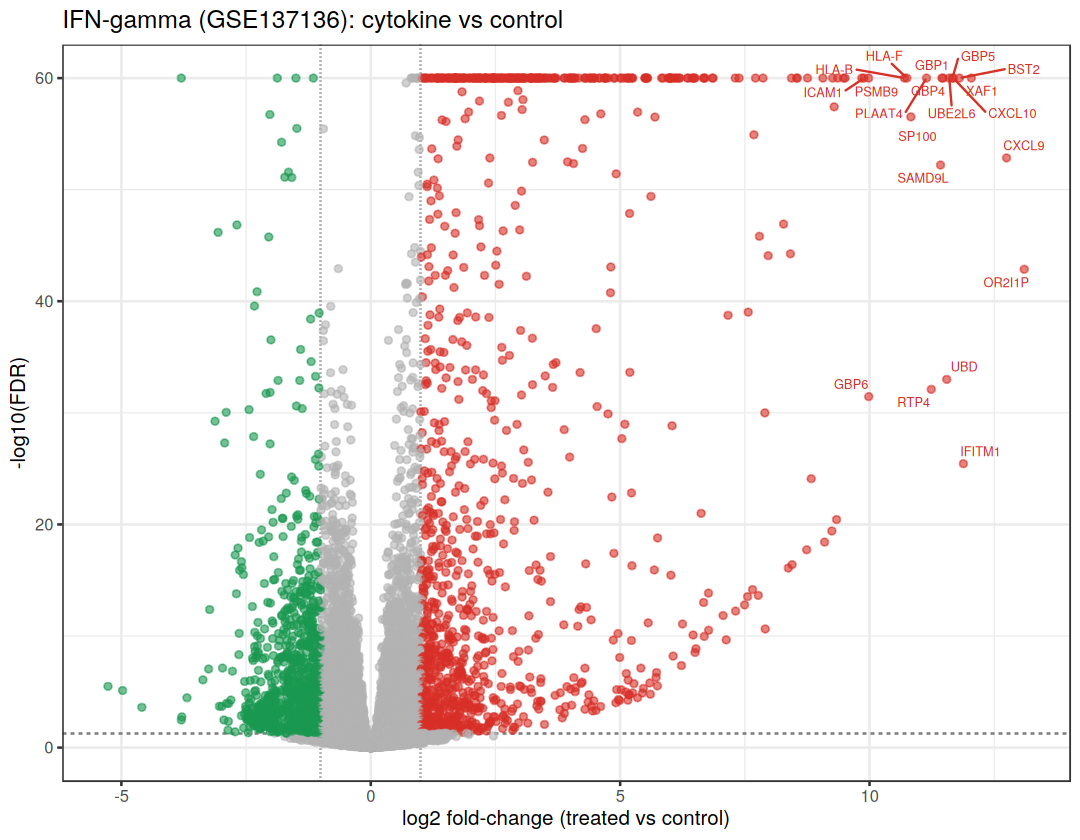

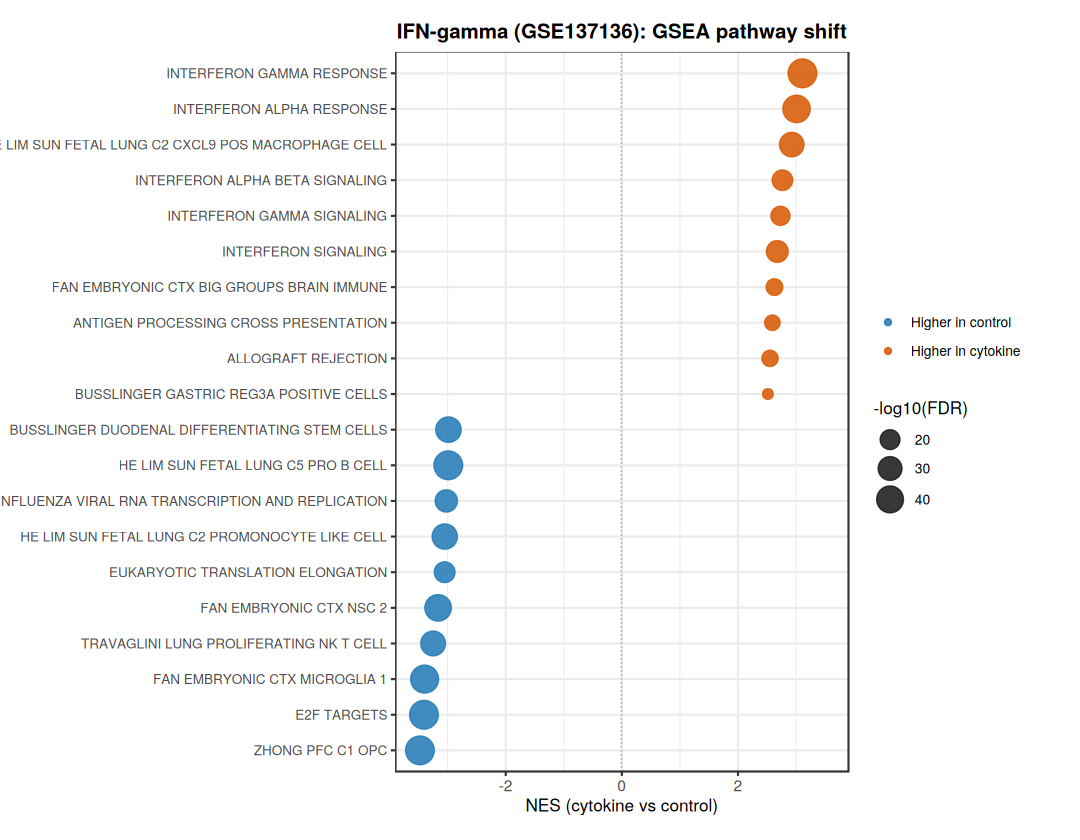

In [27]:
coldata_ifn_gamma <- data.frame(
  row.names = colnames(counts_ifn_gamma),
  condition = factor(
    ifelse(grepl("^ctrl", colnames(counts_ifn_gamma)), "Control", "Cytokine"),
    levels = c("Control", "Cytokine")
  )
)

de_ifn_gamma   <- run_deseq2(counts_ifn_gamma, coldata_ifn_gamma,
                               contrast = c("condition", "Cytokine", "Control"))
gsea_ifn_gamma <- run_gsea(de_ifn_gamma, pathways_fgsea)

n_up <- sum(!is.na(de_ifn_gamma$padj) & de_ifn_gamma$padj < 0.05 & de_ifn_gamma$log2FoldChange > 0)
n_dn <- sum(!is.na(de_ifn_gamma$padj) & de_ifn_gamma$padj < 0.05 & de_ifn_gamma$log2FoldChange < 0)
cat("IFN-gamma DESeq2 sig genes (FDR<0.05): up =", n_up, "| down =", n_dn, "\n")

n_gsea_up <- sum(!is.na(gsea_ifn_gamma$padj) & gsea_ifn_gamma$padj < 0.05 & gsea_ifn_gamma$NES > 0)
n_gsea_dn <- sum(!is.na(gsea_ifn_gamma$padj) & gsea_ifn_gamma$padj < 0.05 & gsea_ifn_gamma$NES < 0)
cat("IFN-gamma GSEA sig pathways (FDR<0.05): up =", n_gsea_up, "| down =", n_gsea_dn, "\n")

# Gene volcano
options(repr.plot.width = 9, repr.plot.height = 7)
print(make_gene_volcano(de_ifn_gamma, title = "IFN-gamma (GSE137136): cytokine vs control"))

# Pathway shift
p_gsea_ifn_gamma <- make_gsea_shift_plot(
  gsea_ifn_gamma, fdr_cutoff = 0.05, nes_cutoff = 0.5,
  treated_name = "cytokine", control_name = "control",
  title = "IFN-gamma (GSE137136): GSEA pathway shift"
)
options(repr.plot.width = 9, repr.plot.height = 7)
print(p_gsea_ifn_gamma)

### IFN-α (GSE133218): DESeq2 + GSEA

converting counts to integer mode



Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.02% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 9 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”


Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-50. You can set the `eps` argument to zero for better estimation.”


IFN-alpha DESeq2 sig genes (FDR<0.05): up = 1976 | down = 1419 


IFN-alpha GSEA sig pathways (FDR<0.05): up = 314 | down = 100 


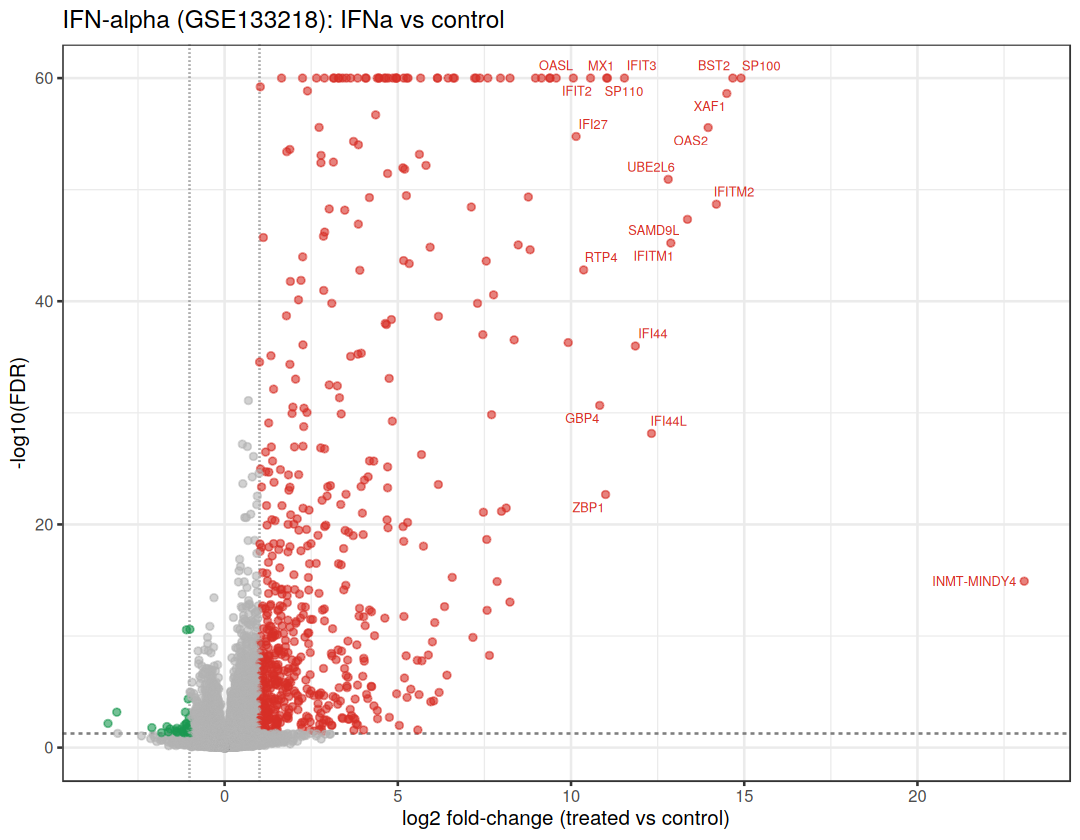

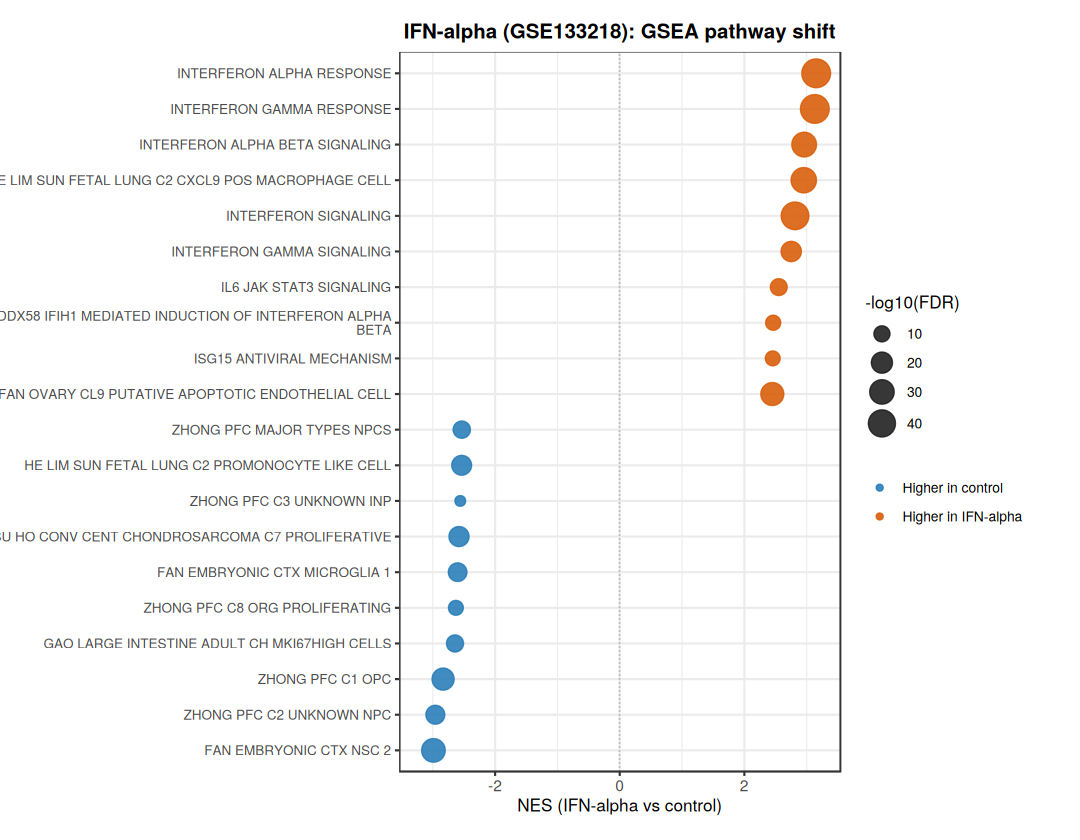

In [28]:
coldata_ifn_alpha <- data.frame(
  row.names = meta_ifn_alpha$sample,
  condition = factor(meta_ifn_alpha$condition, levels = c("Control", "IFNa"))
)

# Keep only columns matching the count matrix column order
counts_ifn_alpha_ord <- counts_ifn_alpha[, meta_ifn_alpha$sample]

de_ifn_alpha   <- run_deseq2(counts_ifn_alpha_ord, coldata_ifn_alpha,
                               contrast = c("condition", "IFNa", "Control"))
gsea_ifn_alpha <- run_gsea(de_ifn_alpha, pathways_fgsea)

n_up <- sum(!is.na(de_ifn_alpha$padj) & de_ifn_alpha$padj < 0.05 & de_ifn_alpha$log2FoldChange > 0)
n_dn <- sum(!is.na(de_ifn_alpha$padj) & de_ifn_alpha$padj < 0.05 & de_ifn_alpha$log2FoldChange < 0)
cat("IFN-alpha DESeq2 sig genes (FDR<0.05): up =", n_up, "| down =", n_dn, "\n")

n_gsea_up <- sum(!is.na(gsea_ifn_alpha$padj) & gsea_ifn_alpha$padj < 0.05 & gsea_ifn_alpha$NES > 0)
n_gsea_dn <- sum(!is.na(gsea_ifn_alpha$padj) & gsea_ifn_alpha$padj < 0.05 & gsea_ifn_alpha$NES < 0)
cat("IFN-alpha GSEA sig pathways (FDR<0.05): up =", n_gsea_up, "| down =", n_gsea_dn, "\n")

# Gene volcano
options(repr.plot.width = 9, repr.plot.height = 7)
print(make_gene_volcano(de_ifn_alpha, title = "IFN-alpha (GSE133218): IFNa vs control"))

# Pathway shift
p_gsea_ifn_alpha <- make_gsea_shift_plot(
  gsea_ifn_alpha, fdr_cutoff = 0.05, nes_cutoff = 0.5,
  treated_name = "IFN-alpha", control_name = "control",
  title = "IFN-alpha (GSE133218): GSEA pathway shift"
)
options(repr.plot.width = 9, repr.plot.height = 7)
print(p_gsea_ifn_alpha)

### Compare DESeq2+GSEA vs CLAMP

Each scatter shows per-pathway NES from GSEA (x) against log₂FC from CLAMP (y). Points in red are significant (FDR < 0.05) in both methods. High Spearman r means both approaches identify the same directional biology; discordant points indicate what one method detects that the other misses.

Warning message:
“ggrepel: 90 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“ggrepel: 50 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


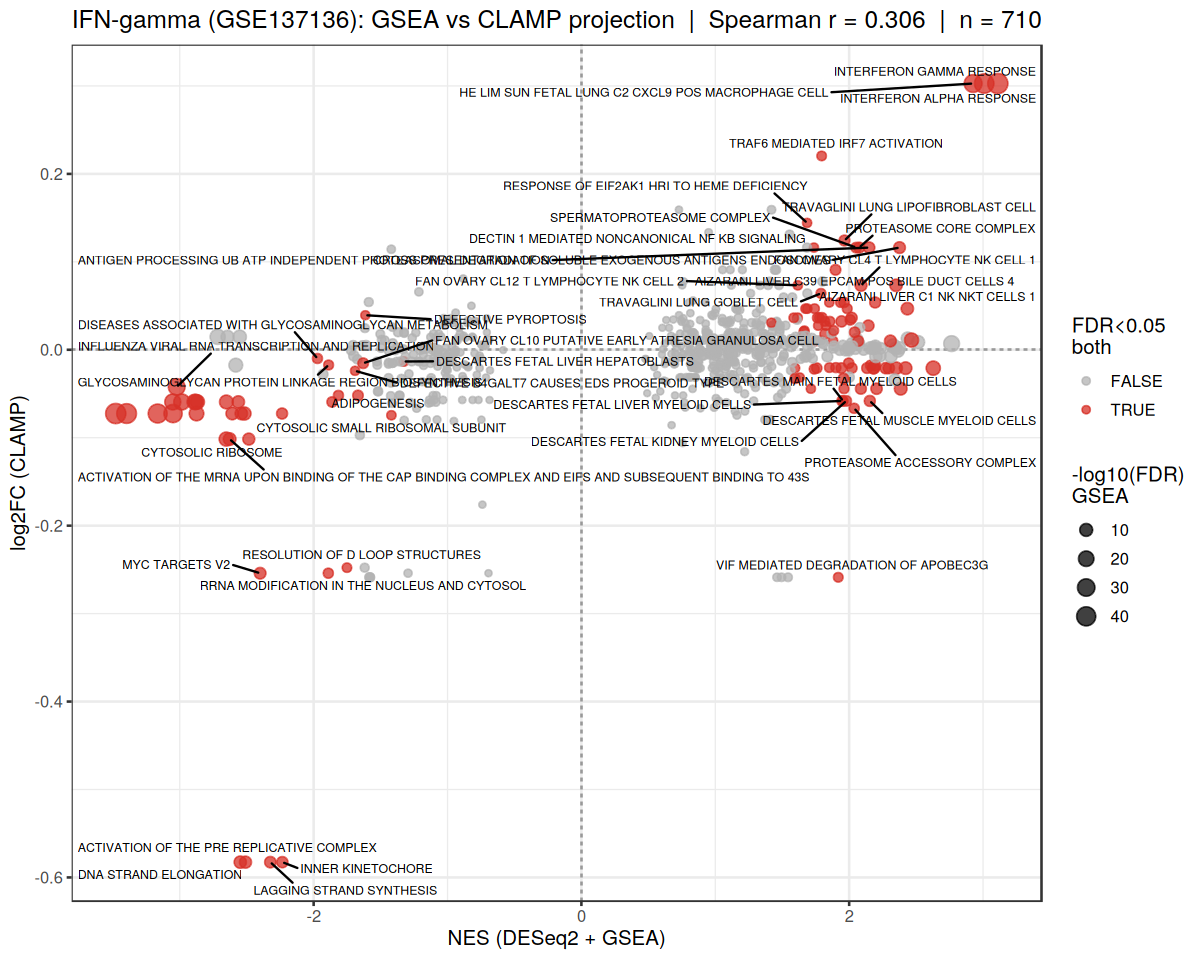

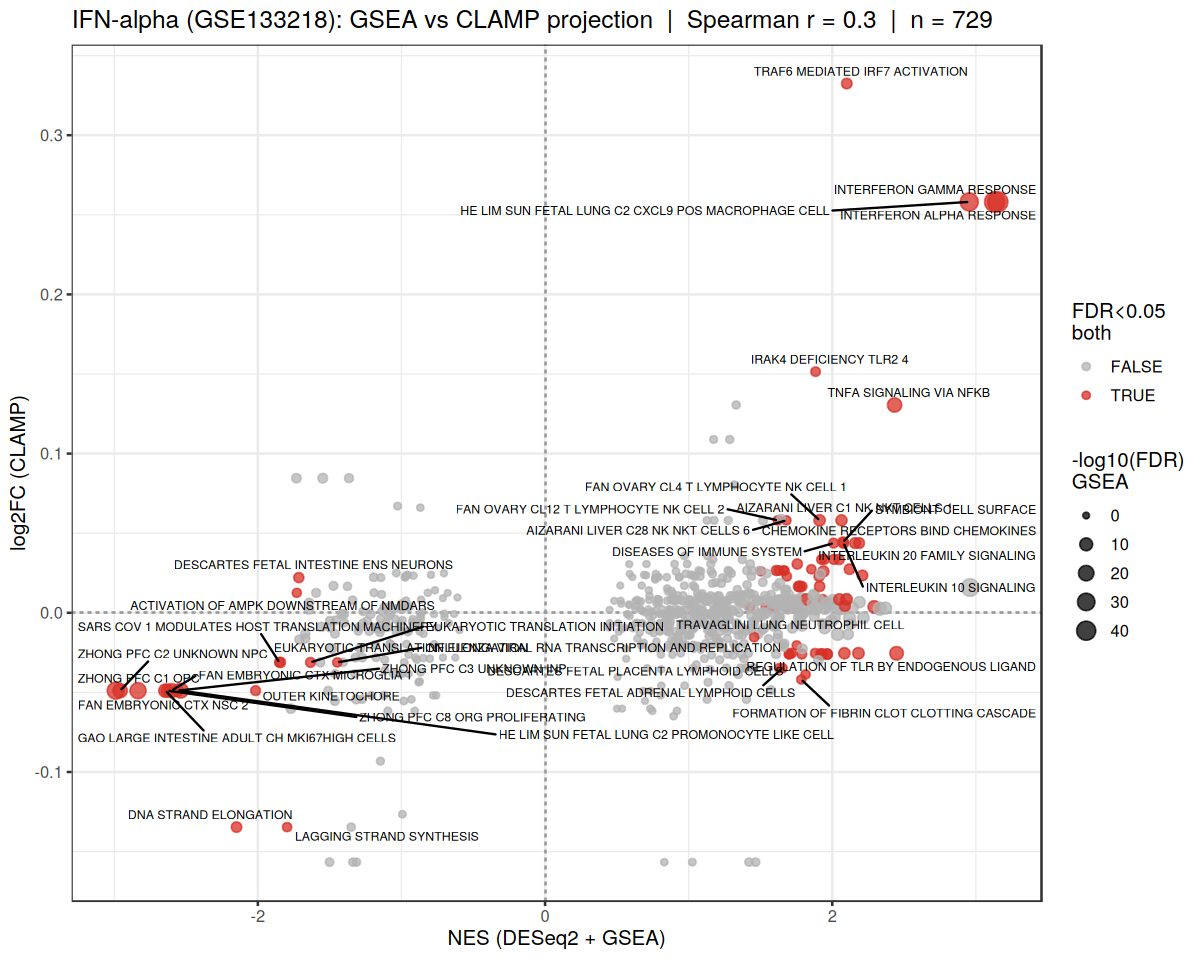

In [29]:
options(repr.plot.width = 10, repr.plot.height = 8)

# IFN-gamma: GSEA vs CLAMP projection
print(make_gsea_vs_clamp_plot(
  gsea_ifn_gamma, rank_ifn_gamma, model,
  title = "IFN-gamma (GSE137136): GSEA vs CLAMP projection"
))

# IFN-alpha: GSEA vs CLAMP projection (all samples)
print(make_gsea_vs_clamp_plot(
  gsea_ifn_alpha, rank_ifn_alpha_all, model,
  title = "IFN-alpha (GSE133218): GSEA vs CLAMP projection"
))

## Compare: projection vs local CLAMP

Same limma pipeline applied to LV scores from each local model. Plots mirror the projection section to make direct visual comparison easy.

### IFN-γ (GSE137136): local model DE

IFN-gamma local model sig LVs (FDR<0.05): up = 1 | down = 2 


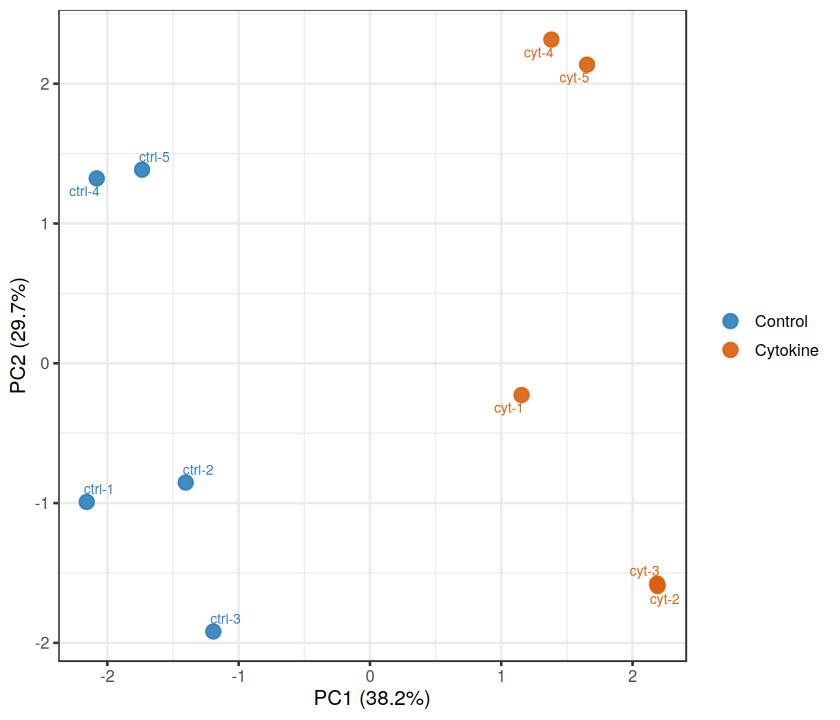

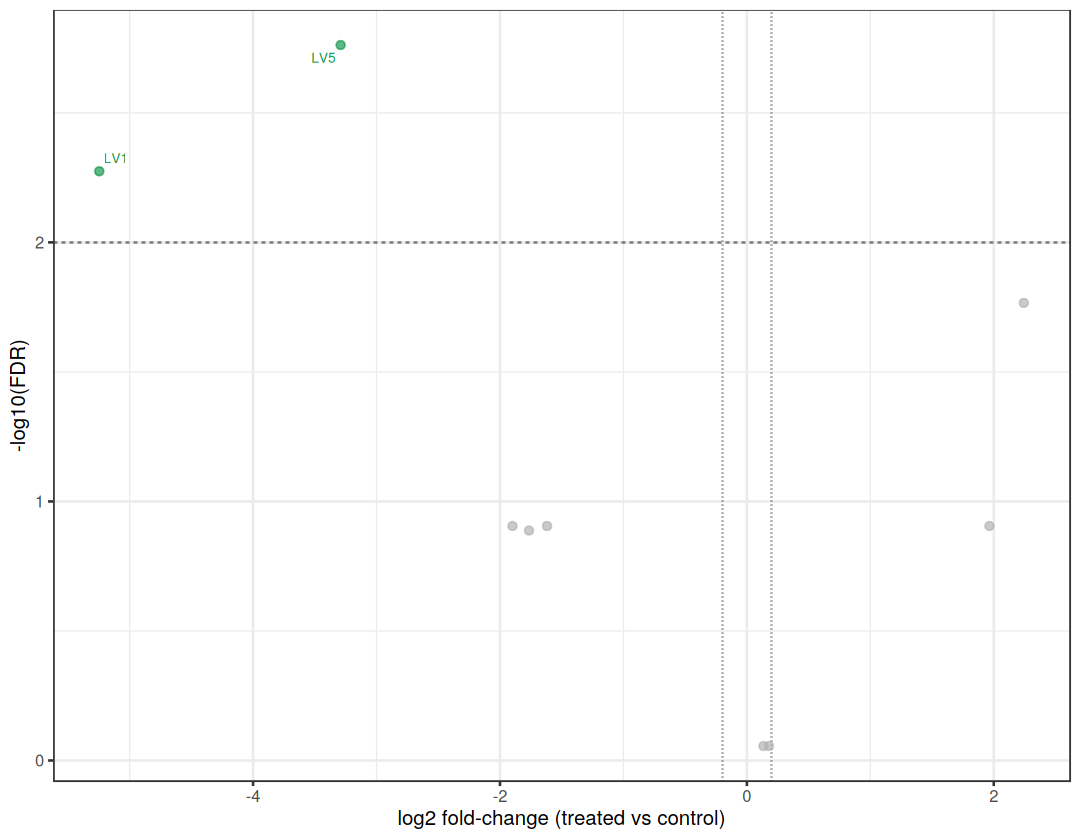

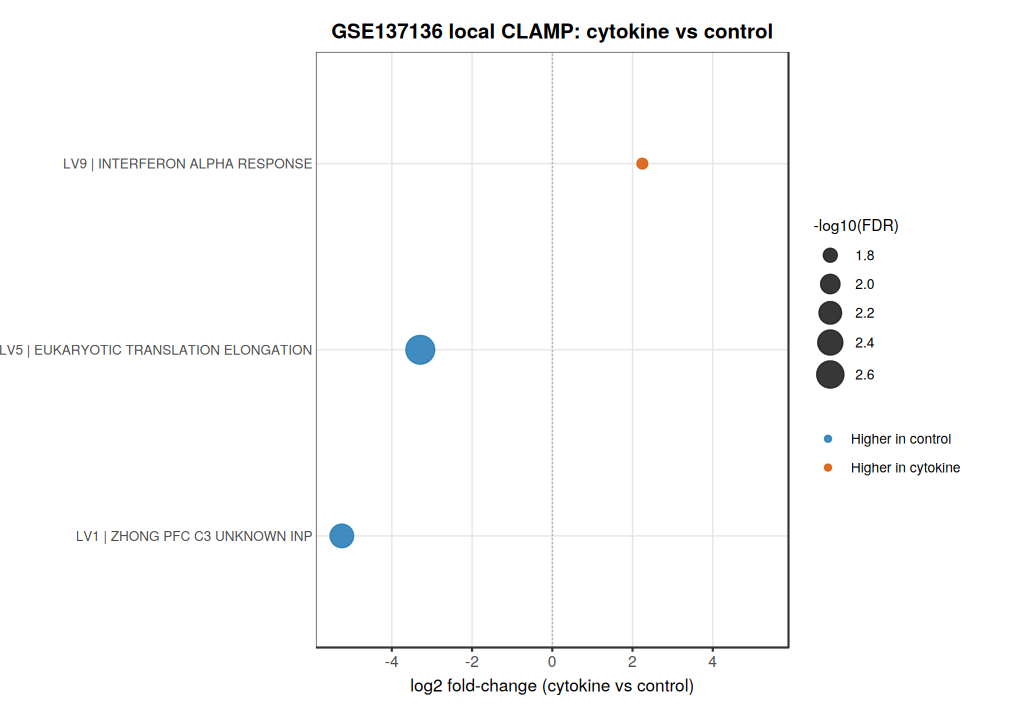

In [30]:
B_ifn_gamma_local    <- as.matrix(model_ifn_gamma$B)
rank_ifn_gamma_local <- rank_lvs(B_ifn_gamma_local, meta_ifn_gamma, model_ifn_gamma,
                                  contrast = c("Cytokine", "Control"))

n_up_local <- sum(rank_ifn_gamma_local$adj.P.Val < 0.05 & rank_ifn_gamma_local$logFC > 0)
n_dn_local <- sum(rank_ifn_gamma_local$adj.P.Val < 0.05 & rank_ifn_gamma_local$logFC < 0)
cat("IFN-gamma local model sig LVs (FDR<0.05): up =", n_up_local, "| down =", n_dn_local, "\n")

# PCA
options(repr.plot.width = 7, repr.plot.height = 6)
print(make_pca_plot(B_ifn_gamma_local, meta_ifn_gamma))

# Volcano
options(repr.plot.width = 9, repr.plot.height = 7)
print(make_volcano(rank_ifn_gamma_local))

# Signed pathway shift
p_ifn_gamma_local <- make_signed_pathway_shift_plot(
  rank_ifn_gamma_local, model_ifn_gamma,
  treated_name = "cytokine", control_name = "control",
  title        = "GSE137136 local CLAMP: cytokine vs control",
  fdr_cutoff   = 0.05, lfc_cutoff = 0.1
)
if (!is.null(attr(p_ifn_gamma_local, "suggested_width"))) {
  options(repr.plot.width  = attr(p_ifn_gamma_local, "suggested_width"),
          repr.plot.height = attr(p_ifn_gamma_local, "suggested_height"))
}
print(p_ifn_gamma_local)


### IFN-α (GSE133218): local model DE

IFN-alpha local model (all samples) - up: 2 | down: 4 


2h - up: 1 | down: 0 
8h - up: 1 | down: 4 
24h - up: 4 | down: 3 


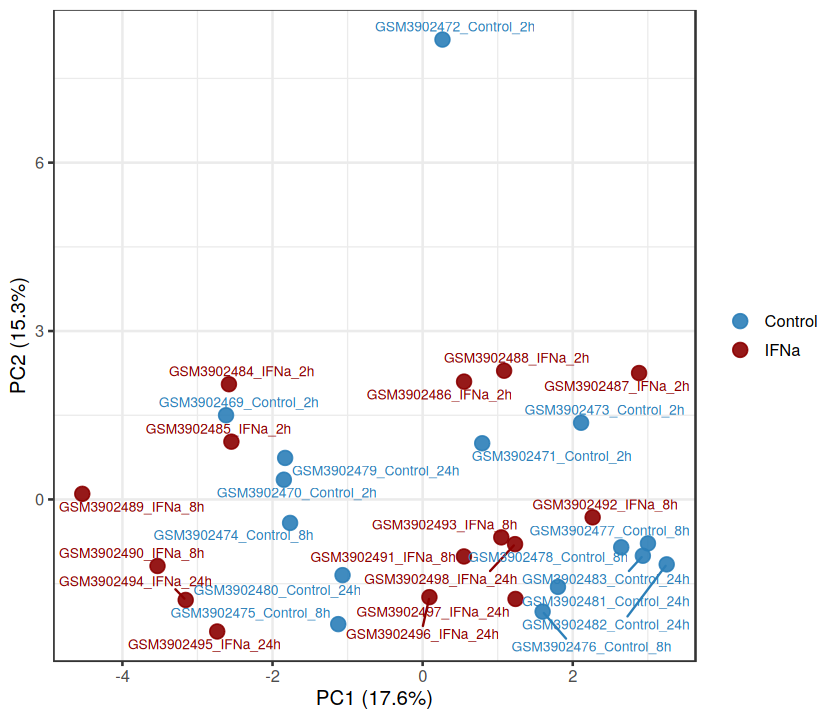

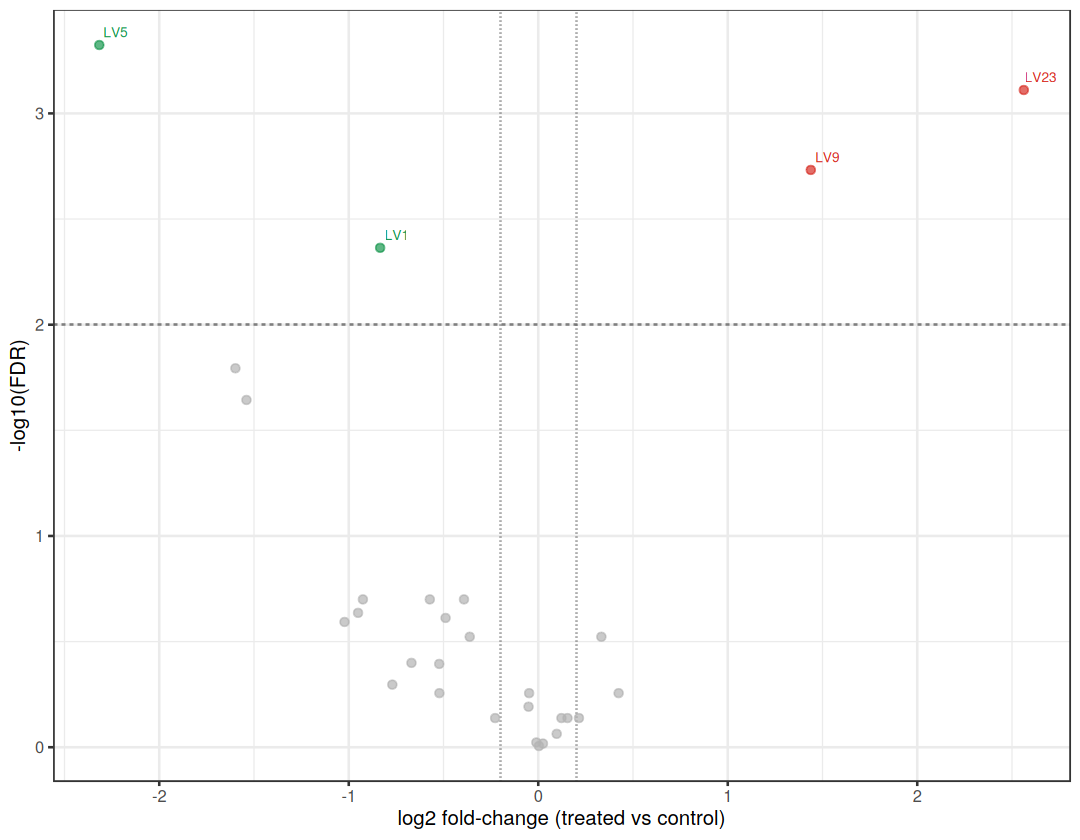

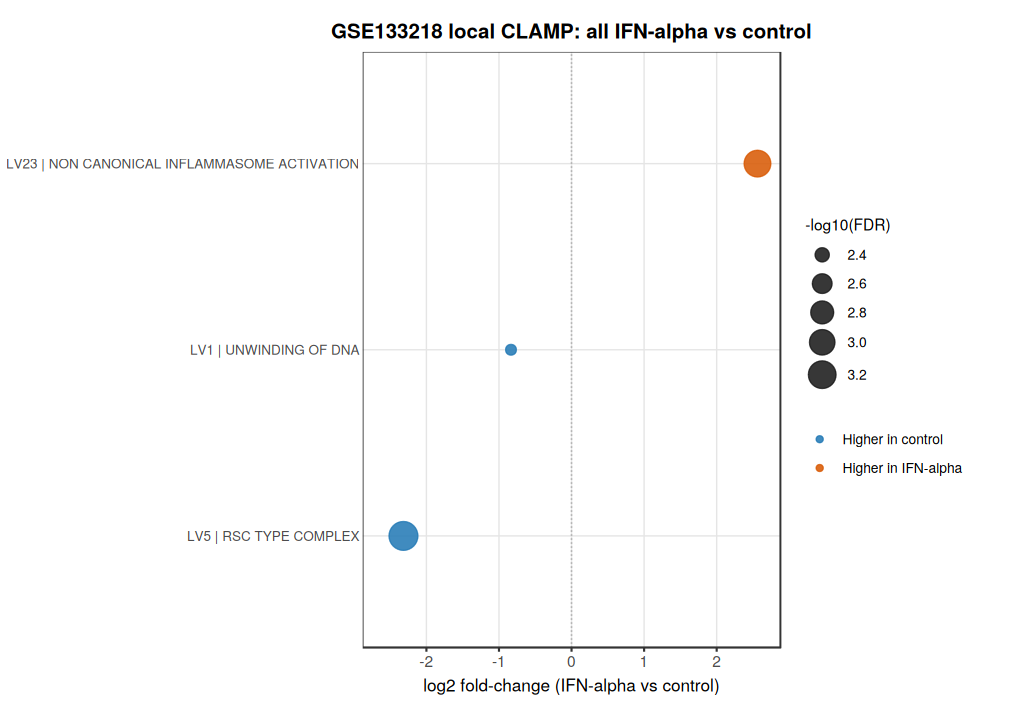

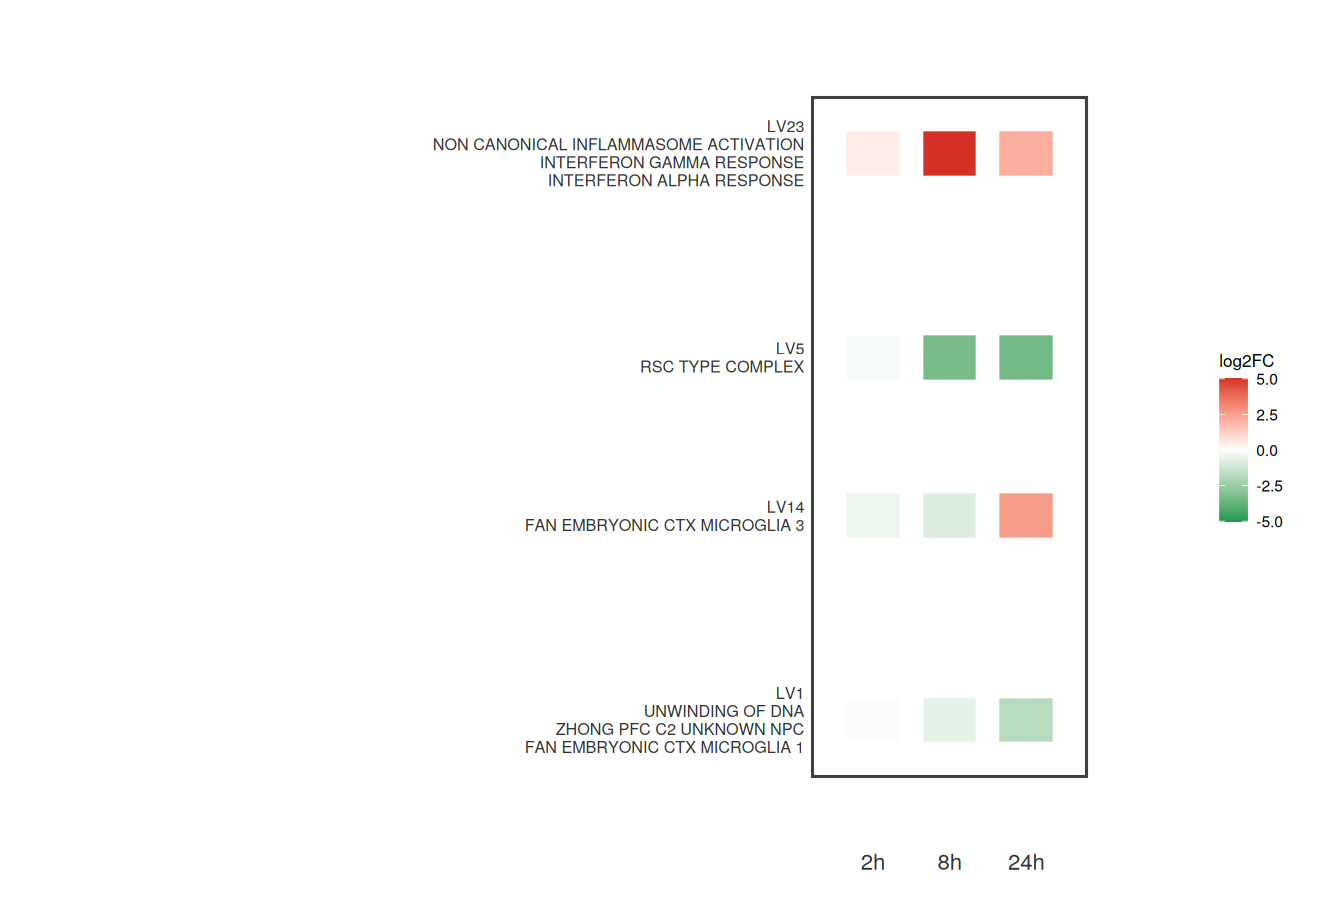

In [31]:
B_ifn_alpha_local    <- as.matrix(model_ifn_alpha$B)
meta_ifn_alpha_local <- meta_ifn_alpha[match(colnames(B_ifn_alpha_local), meta_ifn_alpha$sample), ]

rank_ifn_alpha_local_all <- rank_lvs(B_ifn_alpha_local, meta_ifn_alpha_local, model_ifn_alpha,
                                      contrast = c("IFNa", "Control"))
rank_ifn_alpha_local     <- rank_lvs_6grp(B_ifn_alpha_local, meta_ifn_alpha_local, model_ifn_alpha)

n_up_all <- sum(rank_ifn_alpha_local_all$adj.P.Val < 0.05 & rank_ifn_alpha_local_all$logFC > 0)
n_dn_all <- sum(rank_ifn_alpha_local_all$adj.P.Val < 0.05 & rank_ifn_alpha_local_all$logFC < 0)
cat("IFN-alpha local model (all samples) - up:", n_up_all, "| down:", n_dn_all, "\n")
for (tp in names(rank_ifn_alpha_local)) {
  n_u <- sum(rank_ifn_alpha_local[[tp]]$adj.P.Val < 0.05 & rank_ifn_alpha_local[[tp]]$logFC > 0)
  n_d <- sum(rank_ifn_alpha_local[[tp]]$adj.P.Val < 0.05 & rank_ifn_alpha_local[[tp]]$logFC < 0)
  cat(tp, "- up:", n_u, "| down:", n_d, "\n")
}

# PCA
options(repr.plot.width = 7, repr.plot.height = 6)
print(make_pca_plot(B_ifn_alpha_local, meta_ifn_alpha_local))

# Volcano - all samples
options(repr.plot.width = 9, repr.plot.height = 7)
print(make_volcano(rank_ifn_alpha_local_all))

# Signed pathway shift - all samples
p_ifn_alpha_local <- make_signed_pathway_shift_plot(
  rank_ifn_alpha_local_all, model_ifn_alpha,
  treated_name = "IFN-alpha", control_name = "control",
  title = "GSE133218 local CLAMP: all IFN-alpha vs control",
  fdr_cutoff = 0.05, lfc_cutoff = 0.1
)
if (!is.null(attr(p_ifn_alpha_local, "suggested_width"))) {
  options(repr.plot.width  = attr(p_ifn_alpha_local, "suggested_width"),
          repr.plot.height = attr(p_ifn_alpha_local, "suggested_height"))
}
print(p_ifn_alpha_local)

# Time-course heatmap (local model)
p_hm_ifn_alpha_local <- make_ifna_heatmap(
  rank_133_list      = rank_ifn_alpha_local,
  mdl                = model_ifn_alpha,
  de_fdr_cutoff      = 0.05,
  lfc_cutoff         = 0.1,
  pathway_fdr_cutoff = 0.05,
  auc_cutoff         = 0.7,
  max_lvs            = 12,
  max_paths_per_lv   = 3
)
if (!is.null(p_hm_ifn_alpha_local)) {
  options(repr.plot.width  = attr(p_hm_ifn_alpha_local, "suggested_width"),
          repr.plot.height = attr(p_hm_ifn_alpha_local, "suggested_height"))
  print(p_hm_ifn_alpha_local)
}


In [32]:
head(rank_ifn_alpha_local_all)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,LV,pathways,top_AUC,n_paths,abs_logFC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>
1,-2.316489,1.323016e-16,-5.139473,1.636380e-05,0.0004745502,2.9028605,LV5,RSC TYPE COMPLEX,0.9068325,1,2.316489
2,2.562322,-3.686866e-16,4.717099,5.344346e-05,0.0007749302,1.7596171,LV23,NON CANONICAL INFLAMMASOME ACTIVATION | INTERFERON GAMMA RESPONSE | INTERFERON ALPHA RESPONSE | HE LIM SUN FETAL LUNG C2 CXCL9 POS MACROPHAGE CELL,0.9994983,4,2.562322
3,1.438289,-2.203677e-16,4.258372,1.915631e-04,0.0018517768,0.5317711,LV9,unannotated,0.0000000,0,1.438289
4,-0.834354,4.949744e-17,-3.843591,5.967541e-04,0.0043264670,-0.5541143,LV1,UNWINDING OF DNA | ZHONG PFC C2 UNKNOWN NPC | FAN EMBRYONIC CTX MICROGLIA 1 | GAO LARGE INTESTINE ADULT CH MKI67HIGH CELLS | ZHONG PFC C3 UNKNOWN INP | ZHONG PFC C1 OPC | DNA STRAND ELONGATION,0.9993414,7,0.834354
5,-1.598132,7.193320e-16,-3.264472,2.772837e-03,0.0160824533,-2.0056301,LV6,unannotated,0.0000000,0,1.598132
6,-1.539887,3.561966e-16,-3.058035,4.699441e-03,0.0227139640,-2.4978482,LV26,unannotated,0.0000000,0,1.539887


### Pathway-level comparison: ARCHS4 projection vs local CLAMP

For each pathway, the best LV (lowest FDR) is selected from each model independently. Points in red are significant (FDR < 0.05) in both models. Dotted diagonal = perfect agreement; Spearman r over all shared annotated pathways.

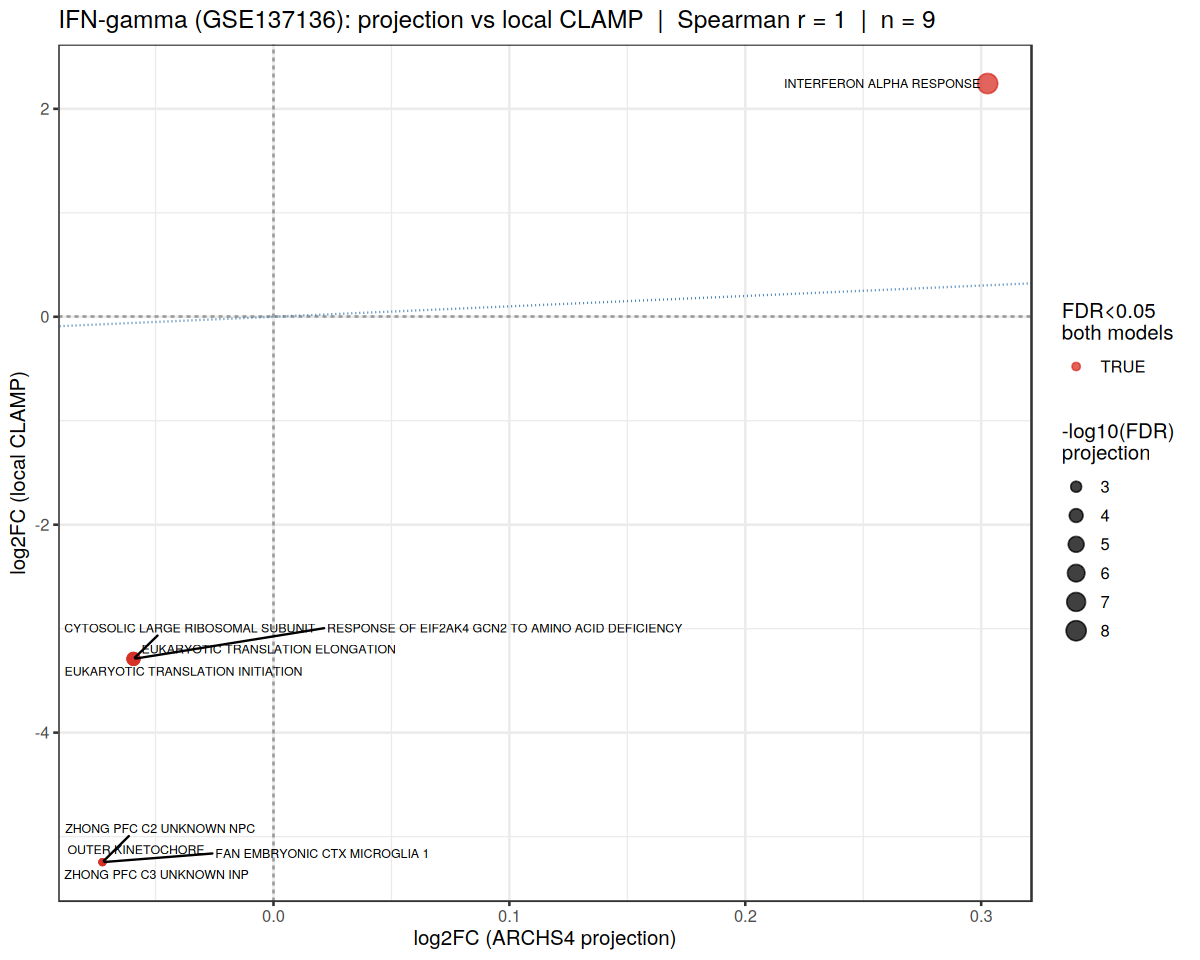

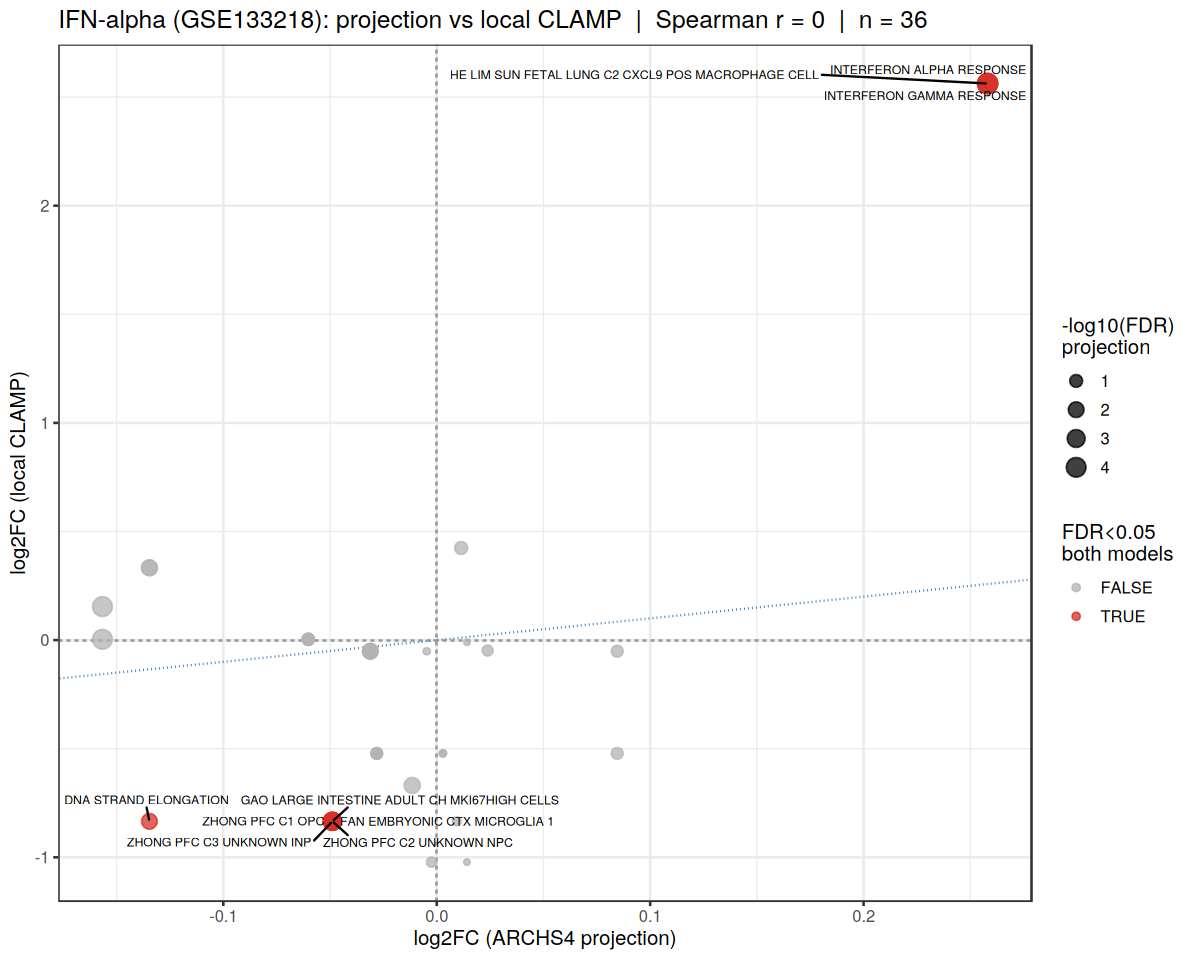

In [33]:
options(repr.plot.width = 10, repr.plot.height = 8)

# IFN-gamma
print(make_comparison_plot(
  rank_ifn_gamma, rank_ifn_gamma_local, model, model_ifn_gamma,
  title = "IFN-gamma (GSE137136): projection vs local CLAMP"
))

# IFN-alpha (all samples)
print(make_comparison_plot(
  rank_ifn_alpha_all, rank_ifn_alpha_local_all, model, model_ifn_alpha,
  title = "IFN-alpha (GSE133218): projection vs local CLAMP"
))

Option 2 is the better match to the Colli et al. IFNα beta-cell paper because it captures the main biology described in the study: interferon response, ER stress, proteasome/protein degradation, and innate immune signaling. For example, LV307 directly contains “INTERFERON ALPHA RESPONSE” and “INTERFERON GAMMA RESPONSE,” which matches the experimental design where EndoC-βH1 beta cells and human islets were treated with IFNα. In addition, LV786 captures ER chaperone/IRE1α stress pathways, and LV1269 captures proteasome/translation-related pathways, both of which are explicitly described in the paper as part of the IFNα-induced beta-cell response. In contrast, option 1 has one strong relevant LV, LV23, but the rest of the significant LVs are mostly DNA replication, mitochondrial translation, RNA cap binding, or unannotated, which are less central to the paper’s main message

### DESeq2+GSEA: top enriched pathways

Top pathways by NES enriched in cytokine/IFNα (orange) and in control (blue). FDR < 0.05, |NES| ≥ 0.5. Same pathway set as the CLAMP models (Hallmark, Reactome, GO-CC, C8).

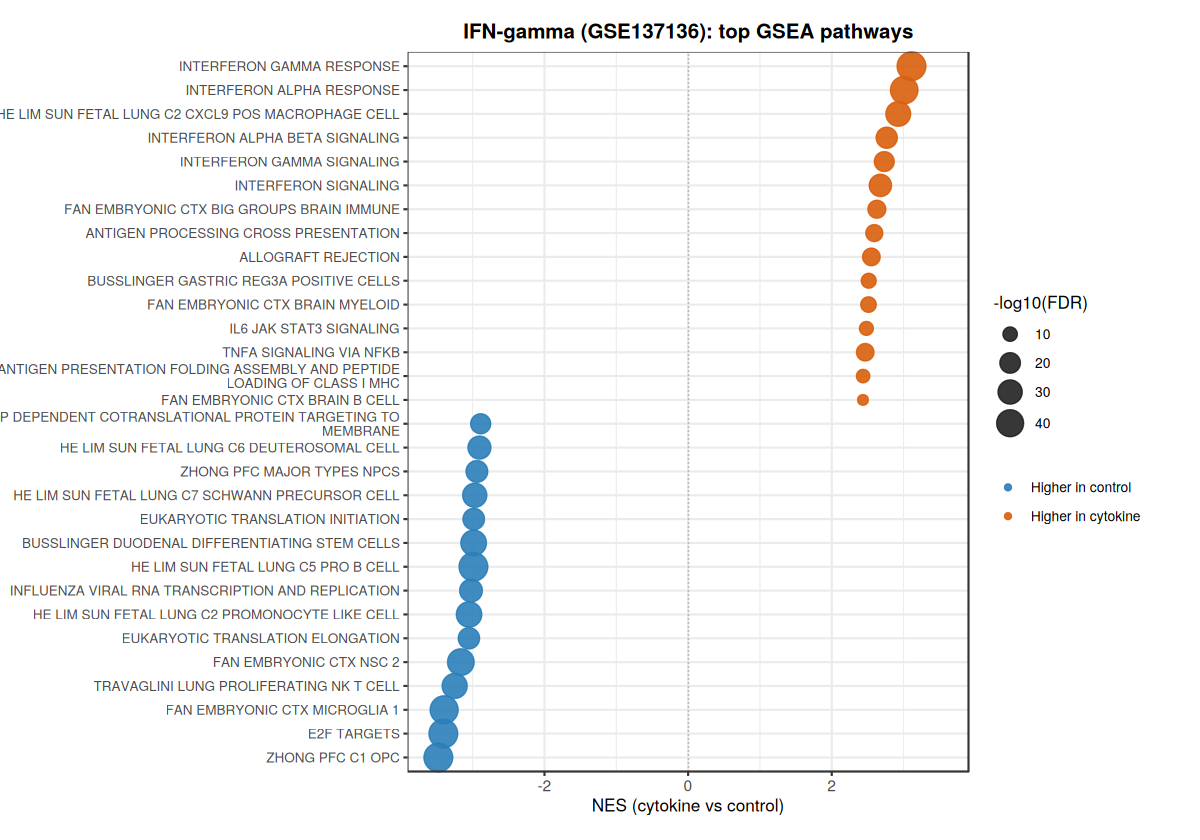

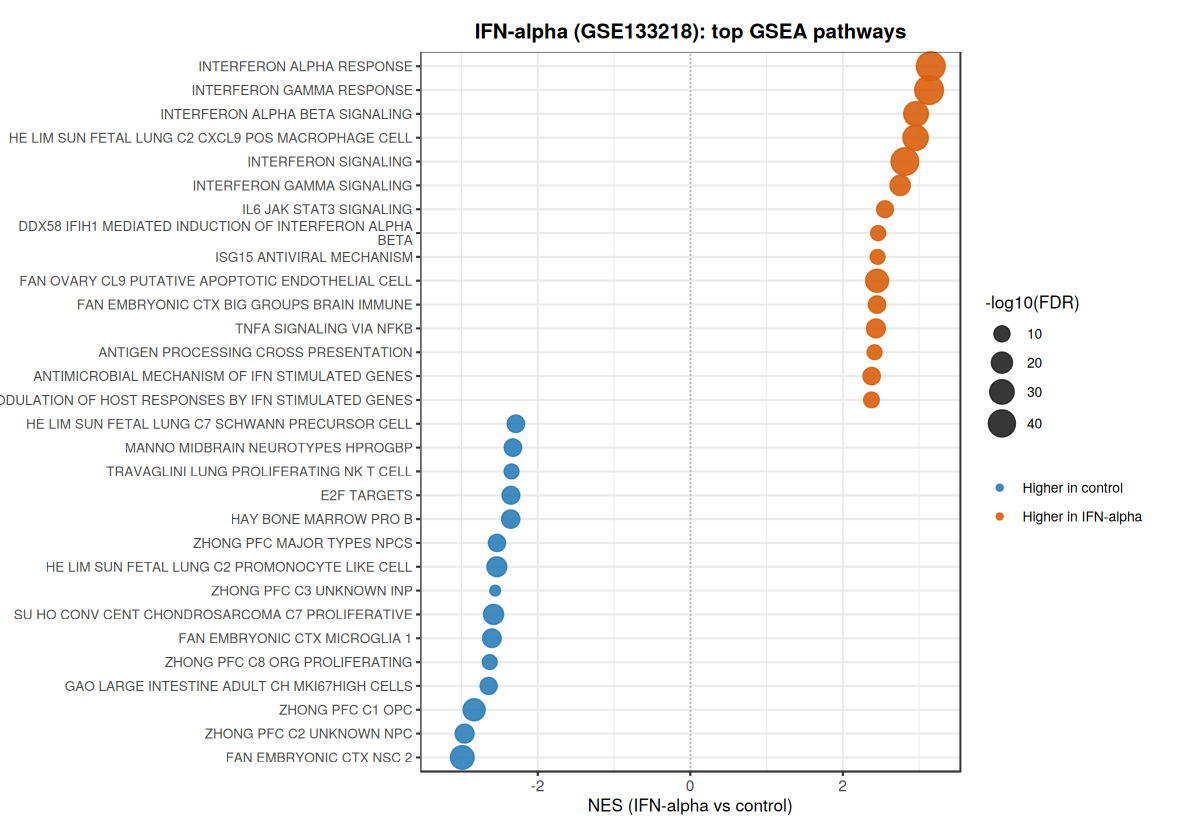

In [34]:
# IFN-gamma (GSE137136): top enriched pathways
p_top_ifn_gamma <- make_gsea_shift_plot(
  gsea_ifn_gamma,
  fdr_cutoff   = 0.05,
  nes_cutoff   = 0.5,
  top_n        = 15,
  treated_name = "cytokine",
  control_name = "control",
  title        = "IFN-gamma (GSE137136): top GSEA pathways"
)
options(repr.plot.width = 10, repr.plot.height = 7)
print(p_top_ifn_gamma)

# IFN-alpha (GSE133218): top enriched pathways
p_top_ifn_alpha <- make_gsea_shift_plot(
  gsea_ifn_alpha,
  fdr_cutoff   = 0.05,
  nes_cutoff   = 0.5,
  top_n        = 15,
  treated_name = "IFN-alpha",
  control_name = "control",
  title        = "IFN-alpha (GSE133218): top GSEA pathways"
)
options(repr.plot.width = 10, repr.plot.height = 7)
print(p_top_ifn_alpha)

## Tissue / Cell-type Inference (PhenoPlier-style)

Adapts the [PhenoPlier tissue inference approach](https://github.com/greenelab/phenoplier/blob/main/nbs/99_demo/02-LV_cell_types-LV603.ipynb) to ARCHS4 + R.

**How it works:** For a selected LV, the ARCHS4 B-matrix weights of all training samples are sorted and the top 2 % are retrieved with their GEO metadata (`source_name_ch1`, `characteristics_ch1`). Labels are combined in priority order (primary source → characteristics fallback → "NOT CATEGORIZED") and displayed as a strip plot of B-scores by cell type: mirroring the PhenoPlier catplot.

**Difference from `02_CRISPRCas9/02_tissue_inference.ipynb`:**  That notebook focuses on a single hardcoded LV (LV702), takes only the top 1 % of samples, and runs a Fisher enrichment test for a specific cell type (HepG2). This section produces a **distributional strip plot** for the most significant LVs from the cytokine DE results: exploratory rather than hypothesis-testing.

**Difference from PhenoPlier:**  PhenoPlier uses recount2 data with many curated metadata columns (`cell type`, `celltype`, `tissue`) and the Python `LVAnalysis` class. Here we use ARCHS4 HDF5 metadata and R, selecting LVs that are significantly up-regulated in the pro-inflammatory cytokine experiments.

In [35]:
library(stringr)
library(archs4r)

# Top up-regulated LV in IFN-gamma (GSE137136) by significance + effect size
lv_selected <- rank_ifn_gamma |>
  dplyr::filter(adj.P.Val < 0.01, logFC > 0) |>
  dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC)) |>
  dplyr::slice_head(n = 1) |>
  dplyr::pull(LV)

# Override manually if needed, e.g.:
# lv_selected <- "LV603"

cat("Selected LV:", lv_selected, "\n")

rank_ifn_gamma |>
  dplyr::filter(LV == lv_selected) |>
  dplyr::select(LV, logFC, adj.P.Val, pathways, top_AUC)

Loading required package: rhdf5



Loading required package: preprocessCore



Loading required package: bit64



Loading required package: bit




Attaching package: ‘bit’




...

The following object is masked from ‘package:utils’:

    hashtab




The following objects are masked from ‘package:base’:

    :, %in%, colSums, is.double, match, order, rank, rowSums




Loading required package: jsonlite



Selected LV: LV307 


LV,logFC,adj.P.Val,pathways,top_AUC
<chr>,<dbl>,<dbl>,<chr>,<dbl>
LV307,0.3027305,8.931028e-09,INTERFERON ALPHA RESPONSE | INTERFERON GAMMA RESPONSE | HE LIM SUN FETAL LUNG C2 CXCL9 POS MACROPHAGE CELL,0.9885902


In [36]:
archs4_B_full <- as.matrix(model$B)

lv_vec  <- sort(archs4_B_full[lv_selected, ], decreasing = TRUE)
TOP_PCT <- 0.02                                # top 2 %, like PhenoPlier uses all; 1 % used in tissue_inference.ipynb
n_top   <- ceiling(length(lv_vec) * TOP_PCT)
top_samples <- names(lv_vec)[seq_len(n_top)]

cat("ARCHS4 training samples (total):", length(lv_vec), "\n")
cat(sprintf("Top %.0f%% count: %d\n", TOP_PCT * 100, n_top))
cat("B-score range in top samples: [",
    round(min(lv_vec[top_samples]), 3), ",",
    round(max(lv_vec[top_samples]), 3), "]\n")
head(lv_vec, 20)

ARCHS4 training samples (total): 605614 


Top 2% count: 12113


B-score range in top samples: [ 0.126 , 0.355 ]


GSM2914724 GSM2914725 GSM2492658 GSM2492662 GSM5340668 GSM5562548 GSM2492660 
 0.3550843  0.3447105  0.3331353  0.3326225  0.3317404  0.3292523  0.3271198 
GSM5562546 GSM5562544 GSM4334001 GSM5293836 GSM2492659 GSM5562547 GSM3341025 
 0.3258846  0.3227884  0.3196962  0.3181971  0.3177106  0.3165991  0.3160184 
GSM2607569 GSM4092388 GSM4092389 GSM5586138 GSM5293837 GSM4813414 
 0.3141076  0.3131389  0.3123197  0.3123119  0.3114546  0.3101571

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [37]:
h5file_archs4 <- here("data/archs4/human_gene_v2.5.h5")
meta_fields   <- c("geo_accession", "series_id", "source_name_ch1", "characteristics_ch1")

meta_top <- as.data.frame(
  a4.meta.samples(h5file_archs4, top_samples, meta_fields = meta_fields, silent = TRUE),
  stringsAsFactors = FALSE
)
meta_top <- meta_top[top_samples, ]
meta_top$B_score <- lv_vec[rownames(meta_top)]

cat("Metadata retrieved for", nrow(meta_top), "samples\n")
head(meta_top, 10)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': object 'h5file' not found


In [ ]:
# PhenoPlier combines multiple metadata columns with backfill (cell type → celltype → tissue).
# In ARCHS4 the equivalent is: source_name_ch1 → first token of characteristics_ch1 → NOT CATEGORIZED.
meta_top <- meta_top |>
  dplyr::mutate(
    cell_type = dplyr::case_when(
      !is.na(source_name_ch1) & nchar(stringr::str_trim(source_name_ch1)) > 0 ~
        stringr::str_trim(source_name_ch1),
      !is.na(characteristics_ch1) & nchar(stringr::str_trim(characteristics_ch1)) > 0 ~
        stringr::str_trim(stringr::str_extract(characteristics_ch1, "^[^;:\\n]+")),
      TRUE ~ "NOT CATEGORIZED"
    )
  )

# Inspect: update the label_map in the next cell based on this output
meta_top |>
  dplyr::count(cell_type, sort = TRUE) |>
  dplyr::slice_head(n = 25)

In [ ]:
# Update this map after inspecting the frequency table above.
# Pattern mirrors PhenoPlier's replace() call that merges synonyms before plotting.
label_map <- c(
  # "whole blood"                          = "Whole blood",
  # "Whole Blood"                          = "Whole blood",
  # "pbmc"                                 = "PBMC",
  # "peripheral blood mononuclear cells"   = "PBMC",
  # "human islet"                          = "Human islets",
)

meta_top <- meta_top |>
  dplyr::mutate(cell_type = dplyr::recode(cell_type, !!!label_map))

N_TOP_ATTRS <- 10
attr_order <- meta_top |>
  dplyr::group_by(cell_type) |>
  dplyr::summarise(max_B = max(B_score, na.rm = TRUE), .groups = "drop") |>
  dplyr::arrange(dplyr::desc(max_B)) |>
  dplyr::slice_head(n = N_TOP_ATTRS) |>
  dplyr::pull(cell_type)

plot_data <- meta_top |>
  dplyr::filter(cell_type %in% attr_order) |>
  dplyr::mutate(cell_type = factor(cell_type, levels = rev(attr_order)))

cat("Top cell types by max B-score:\n")
print(attr_order)

In [ ]:
# Strip plot mirroring PhenoPlier's seaborn catplot(kind="strip").
# Samples are points; x-axis = cell type / tissue; y-axis = LV B-score.
options(repr.plot.width = 10, repr.plot.height = 5)

lv_pathway_label <- rank_ifn_gamma$pathways[rank_ifn_gamma$LV == lv_selected][1]

ggplot2::ggplot(plot_data, ggplot2::aes(x = cell_type, y = B_score)) +
  ggplot2::geom_jitter(width = 0.22, alpha = 0.55, size = 1.6, colour = "#2171b5") +
  ggplot2::coord_flip() +
  ggplot2::labs(
    title    = paste0("ARCHS4 tissue / cell-type inference: ", lv_selected,
                      sprintf(" (top %.0f%% samples)", TOP_PCT * 100)),
    subtitle = paste("Pathway:", lv_pathway_label),
    x        = NULL,
    y        = paste(lv_selected, "B-score")
  ) +
  ggplot2::theme_bw(base_size = 12) +
  ggplot2::theme(panel.grid.major.y = ggplot2::element_blank())

### Debug: uncategorized samples

Samples labelled "NOT CATEGORIZED" have no usable value in either `source_name_ch1` or `characteristics_ch1`. Use the `series_id` to look them up manually (e.g. `https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=<GSE_ID>`), then add the correct label to `label_map` above or hard-code corrections with `dplyr::case_when()`. Once categorized, remove them via `dplyr::filter(cell_type != "NOT CATEGORIZED")`.

In [ ]:
meta_top |>
  dplyr::filter(cell_type == "NOT CATEGORIZED") |>
  dplyr::arrange(dplyr::desc(B_score)) |>
  dplyr::select(geo_accession, series_id, B_score, source_name_ch1, characteristics_ch1) |>
  dplyr::slice_head(n = 20)

## Related PhenoMeXcan traits for selected shifted LVs

In [ ]:
TRAIT_FDR_CUTOFF <- 0.05

results_dir <- file.path(out_dir, "results")
dir.create(results_dir, recursive = TRUE, showWarnings = FALSE)

trait_path_archs4 <- here(
  "data", "archs4", "traits",
  "hall_coverage_rs100_seed_1_CLAMPfull_hall",
  "gls-summary-phenomexcan.tsv.gz"
)

clean_trait_label <- function(text, wrap_w = 46) {
  if (is.na(text) || trimws(text) == "") return(NA_character_)
  text <- trimws(text)
  blacklist <- c("coffee intake", "job code", "none of the above", "tea intake")
  if (any(vapply(blacklist, function(term) grepl(term, tolower(text), fixed = TRUE), logical(1)))) {
    return(NA_character_)
  }
  text <- gsub("^#", "", text)
  text <- gsub("\\s*\\([^)]*?\\d+[^)]*?\\)", "", text, perl = TRUE)
  text <- gsub("_", " ", text)
  text <- trimws(gsub("\\s+", " ", text))
  if (grepl(":", text, fixed = TRUE)) {
    text <- trimws(sub("^.*?:", "", text))
  }
  if (text == "" || any(vapply(blacklist, function(term) grepl(term, tolower(text), fixed = TRUE), logical(1)))) {
    return(NA_character_)
  }
  text <- paste0(toupper(substr(text, 1, 1)), substr(text, 2, nchar(text)))
  paste(strwrap(text, width = wrap_w), collapse = "\n")
}

get_related_traits <- function(lv_ranked, traits,
                               dataset_name,
                               treated_name = "cytokine",
                               control_name = "control",
                               trait_fdr_cutoff = TRAIT_FDR_CUTOFF,
                               lv_fdr_cutoff = 0.01,
                               lfc_cutoff = 0.2) {
  selected <- lv_ranked %>%
    dplyr::filter(adj.P.Val < lv_fdr_cutoff, abs_logFC >= lfc_cutoff) %>%
    dplyr::mutate(
      direction = dplyr::case_when(
        logFC > 0 ~ paste0("Higher in ", treated_name),
        logFC < 0 ~ paste0("Higher in ", control_name),
        TRUE ~ "No shift"
      )
    ) %>%
    dplyr::select(LV, logFC, adj.P.Val, abs_logFC, direction, pathways, top_AUC, n_paths)

  if (nrow(selected) == 0) return(data.frame())

  traits %>%
    dplyr::filter(LV %in% selected$LV, trait_FDR < trait_fdr_cutoff) %>%
    dplyr::inner_join(selected, by = "LV") %>%
    dplyr::mutate(
      dataset = dataset_name,
      label_clean = vapply(phenotype, clean_trait_label, character(1)),
      trait_neg_log_fdr = -log10(pmax(trait_FDR, .Machine$double.xmin)),
      lv_neg_log_fdr = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    ) %>%
    dplyr::filter(!is.na(label_clean)) %>%
    dplyr::arrange(trait_FDR, adj.P.Val, dplyr::desc(abs_logFC))
}

summarise_related_traits <- function(trait_hits) {
  if (nrow(trait_hits) == 0) {
    return(data.frame(
      dataset = character(), phenotype_id = character(), phenotype = character(),
      direction = character(), n_lvs = integer(), best_trait_FDR = numeric(),
      best_trait_pvalue = numeric(), min_lv_FDR = numeric(),
      max_abs_logFC = numeric(), mean_logFC = numeric(),
      LVs = character(), stringsAsFactors = FALSE
    ))
  }
  trait_hits %>%
    dplyr::group_by(dataset, phenotype_id, phenotype, direction) %>%
    dplyr::summarise(
      n_lvs = dplyr::n_distinct(LV),
      best_trait_FDR = min(trait_FDR, na.rm = TRUE),
      best_trait_pvalue = min(trait_pvalue, na.rm = TRUE),
      min_lv_FDR = min(adj.P.Val, na.rm = TRUE),
      max_abs_logFC = max(abs_logFC, na.rm = TRUE),
      mean_logFC = mean(logFC, na.rm = TRUE),
      LVs = paste(unique(LV), collapse = ", "),
      .groups = "drop"
    ) %>%
    dplyr::arrange(dataset, direction, best_trait_FDR, dplyr::desc(max_abs_logFC))
}

make_trait_shift_plot <- function(trait_hits, dataset_name,
                                  treated_name = "cytokine",
                                  control_name = "control",
                                  top_n_per_direction = 15) {
  direction_levels <- c(
    paste0("Higher in ", control_name),
    paste0("Higher in ", treated_name)
  )
  dir_colors <- setNames(c("#2C7FB8", "#D95F0E"), direction_levels)

  empty_p <- ggplot() + theme_void() +
    annotate("text", x = 0.5, y = 0.5,
             label = paste(dataset_name, "no significant related traits"),
             size = 4, colour = "grey55", hjust = 0.5)

  if (nrow(trait_hits) == 0) return(empty_p)

  plot_df <- trait_hits %>%
    dplyr::filter(dataset == dataset_name) %>%
    dplyr::arrange(trait_FDR, adj.P.Val, dplyr::desc(abs_logFC)) %>%
    dplyr::distinct(label_clean, LV, direction, .keep_all = TRUE) %>%
    dplyr::group_by(direction) %>%
    dplyr::slice_head(n = top_n_per_direction) %>%
    dplyr::ungroup() %>%
    dplyr::mutate(
      label = factor(paste0(label_clean, " (", LV, ")"),
                     levels = rev(unique(paste0(label_clean, " (", LV, ")"))))
    )

  if (nrow(plot_df) == 0) return(empty_p)

  x_lim <- max(abs(plot_df$logFC), na.rm = TRUE) * 1.08
  if (!is.finite(x_lim) || x_lim == 0) x_lim <- 1

  ggplot(plot_df, aes(logFC, label)) +
    geom_vline(xintercept = 0, linetype = "dotted", colour = "grey55") +
    geom_point(aes(size = trait_neg_log_fdr, colour = direction), alpha = 0.9) +
    scale_colour_manual(values = dir_colors, name = NULL) +
    scale_size_continuous(name = "-log10 trait FDR", range = c(2.5, 7.5)) +
    scale_x_continuous(limits = c(-x_lim, x_lim)) +
    labs(
      title = paste0(dataset_name, ": related traits for selected shifted LVs"),
      x = paste0("LV log2 fold-change (", treated_name, " vs ", control_name, ")"),
      y = NULL
    ) +
    theme_bw(base_size = 10) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      axis.text.y = element_text(size = 7.5, lineheight = 0.9),
      legend.position = "right"
    )
}

In [ ]:
archs4_traits <- fread(cmd = paste("zcat", shQuote(trait_path_archs4))) %>%
  as.data.frame() %>%
  dplyr::select(
    phenotype_id = phenotype,
    phenotype    = phenotype_desc,
    LV           = lv,
    trait_pvalue = pvalue,
    trait_FDR    = fdr
  ) %>%
  dplyr::mutate(
    trait_pvalue = as.numeric(trait_pvalue),
    trait_FDR    = as.numeric(trait_FDR)
  )

cat("ARCHS4 traits:", nrow(archs4_traits), "rows |",
    dplyr::n_distinct(archs4_traits$phenotype_id), "phenotypes |",
    dplyr::n_distinct(archs4_traits$LV), "LVs\n")

trait_hits_ifn_gamma <- get_related_traits(
  rank_ifn_gamma, archs4_traits,
  dataset_name = "GSE137136",
  treated_name = "cytokine",
  control_name = "control"
)

trait_hits_ifn_alpha <- get_related_traits(
  rank_ifn_alpha_all, archs4_traits,
  dataset_name = "GSE133218",
  treated_name = "IFN-alpha",
  control_name = "control"
)

trait_hits    <- dplyr::bind_rows(trait_hits_ifn_gamma, trait_hits_ifn_alpha)
trait_summary <- summarise_related_traits(trait_hits)

write.csv(trait_hits,    file.path(results_dir, "ARCHS4_selected_LV_trait_hits.csv"),    row.names = FALSE)
write.csv(trait_summary, file.path(results_dir, "ARCHS4_selected_trait_summary.csv"),    row.names = FALSE)

cat("Related trait hits:", nrow(trait_hits), "\n")
trait_summary %>%
  dplyr::group_by(dataset, direction) %>%
  dplyr::summarise(n_traits = dplyr::n_distinct(phenotype_id), .groups = "drop")

### Trait shift plots

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

print(make_trait_shift_plot(
  trait_hits, "GSE137136",
  treated_name = "cytokine",
  control_name = "control"
))

print(make_trait_shift_plot(
  trait_hits, "GSE133218",
  treated_name = "IFN-alpha",
  control_name = "control"
))

### Trait dataframe for significant LVs by direction

In [ ]:
sig_lv_traits_control_cyt <- trait_hits %>%
  dplyr::mutate(
    projection = "ARCHS4",
    condition_group = dplyr::case_when(
      grepl("^Higher in control", direction) ~ "control",
      TRUE ~ "cyt"
    ),
    lv_log2FC_cyt_vs_control = logFC,
    lv_FDR = adj.P.Val
  ) %>%
  dplyr::select(
    dataset,
    projection,
    condition_group,
    LV,
    lv_log2FC_cyt_vs_control,
    lv_FDR,
    phenotype_id,
    phenotype,
    trait_pvalue,
    trait_FDR,
    direction,
    pathways,
    top_AUC,
    n_paths
  ) %>%
  dplyr::arrange(
    dataset, condition_group, lv_FDR, trait_FDR,
    dplyr::desc(abs(lv_log2FC_cyt_vs_control))
  )

write.csv(
  sig_lv_traits_control_cyt,
  file.path(results_dir, "sig_lv_traits_control_cyt_ARCHS4.csv"),
  row.names = FALSE
)

sig_lv_traits_control_cyt %>%
  dplyr::group_by(dataset, projection, condition_group) %>%
  dplyr::summarise(
    n_lvs   = dplyr::n_distinct(LV),
    n_traits = dplyr::n_distinct(phenotype_id),
    n_rows  = dplyr::n(),
    .groups = "drop"
  )

### Traits for top shifted LVs: cytokine vs control (per dataset)

In [ ]:
make_trait_dot_dir <- function(trait_hits,
                               dataset_name,
                               dir_label,
                               top_n_lvs    = 5,
                               top_n_traits = 30) {
  sub_hits <- trait_hits %>%
    dplyr::filter(dataset == dataset_name, direction == dir_label)

  empty_p <- ggplot() + theme_void() +
    annotate("text", x = 0.5, y = 0.5,
             label = paste(dataset_name, dir_label, ": no hits"),
             size = 4, colour = "grey55", hjust = 0.5)

  if (nrow(sub_hits) == 0) return(empty_p)

  top_lvs <- sub_hits %>%
    dplyr::distinct(LV, abs_logFC, adj.P.Val) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC)) %>%
    dplyr::slice_head(n = top_n_lvs) %>%
    dplyr::pull(LV)

  plot_df <- sub_hits %>%
    dplyr::filter(LV %in% top_lvs) %>%
    dplyr::arrange(trait_FDR, adj.P.Val, dplyr::desc(abs_logFC)) %>%
    dplyr::distinct(label_clean, LV, .keep_all = TRUE) %>%
    dplyr::slice_head(n = top_n_traits) %>%
    dplyr::mutate(
      trait_label = factor(
        paste0(label_clean, " (", LV, ")"),
        levels = rev(unique(paste0(label_clean, " (", LV, ")")))
      ),
      LV = factor(LV, levels = top_lvs)
    )

  if (nrow(plot_df) == 0) return(empty_p)

  ggplot(plot_df, aes(x = trait_neg_log_fdr, y = trait_label,
                      colour = LV, size = abs_logFC)) +
    geom_point(alpha = 0.85) +
    scale_size_continuous(name = "|log2FC| LV", range = c(2, 6)) +
    labs(
      title = paste0(dataset_name, ": ", dir_label),
      x = "-log10(trait FDR)",
      y = NULL,
      colour = "LV"
    ) +
    theme_bw(base_size = 10) +
    theme(
      plot.title    = element_text(size = 11, face = "bold", hjust = 0.5),
      axis.text.y   = element_text(size = 7.5, lineheight = 0.9),
      legend.position = "right"
    )
}

#### Cytokine direction

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7)

print(make_trait_dot_dir(
  trait_hits, "GSE137136", "Higher in cytokine",
  top_n_lvs = 5, top_n_traits = 30
))

print(make_trait_dot_dir(
  trait_hits, "GSE133218", "Higher in IFN-alpha",
  top_n_lvs = 5, top_n_traits = 30
))

#### Control direction

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 7)

print(make_trait_dot_dir(
  trait_hits, "GSE137136", "Higher in control",
  top_n_lvs = 5, top_n_traits = 30
))

print(make_trait_dot_dir(
  trait_hits, "GSE133218", "Higher in control",
  top_n_lvs = 5, top_n_traits = 30
))

## Export for Figure 4

In [ ]:
PANEL_DIR_FIG4 <- here('output/99_panels/fig4')
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)

write.csv(rank_ifn_gamma,       file.path(PANEL_DIR_FIG4, 'cytokine_archs4_ifn_gamma_lvs.csv'),  row.names = FALSE)
write.csv(rank_ifn_alpha_all,   file.path(PANEL_DIR_FIG4, 'cytokine_archs4_ifn_alpha_lvs.csv'),  row.names = FALSE)
write.csv(rank_ifn_gamma_local, file.path(PANEL_DIR_FIG4, 'cytokine_local_ifn_gamma_lvs.csv'),   row.names = FALSE)
write.csv(rank_ifn_alpha_local_all, file.path(PANEL_DIR_FIG4, 'cytokine_local_ifn_alpha_lvs.csv'), row.names = FALSE)

message('Exported cytokine projection data to ', PANEL_DIR_FIG4)

# Save per-timepoint IFNa data for heatmap (2h, 8h, 24h)
for (tp in names(rank_ifn_alpha)) {
    out_tp <- rank_ifn_alpha[[tp]]
    out_tp$timepoint <- tp
    write.csv(out_tp,
              file.path(PANEL_DIR_FIG4, paste0('cytokine_archs4_ifn_alpha_', gsub('h','h',tp), '_lvs.csv')),
              row.names = FALSE)
}
message('Per-timepoint IFNa data exported.')
